**Projet 9: Proof of Concept** 





> "View" > "Table of contents" pour voir le plan du notebook

# 1. Imports et paramétrages

## 1.1 Installation des librairies

In [1]:
!pip install pandas numpy scikit-learn missingno matplotlib


[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1.2 Import des Librairies

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno

import os

from sklearn.preprocessing import StandardScaler

## 1.3 Paramétrages

In [3]:
#parametrage de panda pour afficher toutes les colonnes sans les tronquer
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# # Application des paramètres de style par défaut de Seaborn
# sns.set()

# 2. Quick Tour

Nous allons faire une analyse exploratoire + data engineering sur la base des fichiers fournis.

Pour rappel des fichiers fournis sur Kaggle + description des colonnes:

**Fichiers**
train.csv - historical data including Sales
test.csv - historical data excluding Sales
sample_submission.csv - a sample submission file in the correct format
store.csv - supplemental information about the stores


**Colonnes** 
Most of the fields are self-explanatory. The following are descriptions for those that aren't.

Id - an Id that represents a (Store, Date) duple within the test set
Store - a unique Id for each store
Sales - the turnover for any given day (this is what you are predicting)
Customers - the number of customers on a given day
Open - an indicator for whether the store was open: 0 = closed, 1 = open
StateHoliday - indicates a state holiday. Normally all stores, with few exceptions, are closed on state holidays. Note that all schools are closed on public holidays and weekends. a = public holiday, b = Easter holiday, c = Christmas, 0 = None
SchoolHoliday - indicates if the (Store, Date) was affected by the closure of public schools
StoreType - differentiates between 4 different store models: a, b, c, d
Assortment - describes an assortment level: a = basic, b = extra, c = extended
CompetitionDistance - distance in meters to the nearest competitor store
CompetitionOpenSince[Month/Year] - gives the approximate year and month of the time the nearest competitor was opened
Promo - indicates whether a store is running a promo on that day
Promo2 - Promo2 is a continuing and consecutive promotion for some stores: 0 = store is not participating, 1 = store is participating
Promo2Since[Year/Week] - describes the year and calendar week when the store started participating in Promo2
PromoInterval - describes the consecutive intervals Promo2 is started, naming the months the promotion is started anew. E.g. "Feb,May,Aug,Nov" means each round starts in February, May, August, November of any given year for that store

In [4]:
# Chemin complet du fichier à utiliser:
directory = 'C:/Users/flore/Openclassrooms/Projet 9/Data'
filename_train = "train.csv"
filename_store = "store.csv"

train_path = os.path.join(directory, filename_train)
store_path = os.path.join(directory, filename_store)

# Lire les fichiers CSV
df = pd.read_csv(train_path, decimal=".", low_memory=False)
store = pd.read_csv(store_path, decimal=".", low_memory=False)

In [5]:
# Dimensions du DataFrame
dimensions = df.shape
print('Dimensions:', dimensions)  

Dimensions: (1017209, 9)


In [6]:
# Premières lignes du DataFrame
head = df.head()
print("\nPremières lignes du DataFrame:")
head


Premières lignes du DataFrame:


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [7]:
# Dernières lignes du DataFrame
head = df.tail()
print("\nDernières lignes du DataFrame:")
head


Dernières lignes du DataFrame:


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1
1017208,1115,2,2013-01-01,0,0,0,0,a,1


methode describe pour les variables quantitatives

In [8]:
# Description statistique
description = df.describe()
print("Description statistique:")
description

Description statistique:


,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


methode describe pour les variables qualitatives

In [9]:
df.describe(include=[object])

,Date,StateHoliday
count,1017209,1017209
unique,942,4
top,2013-01-02,0
freq,1115,986159


Identification de lignes en double 

In [10]:
df.duplicated().sum()

np.int64(0)

Aucun doublon.

In [11]:
# Nombre de cellules vides par colonne
missing_values = df.isnull().sum()
print("\nNombre de cellules vides par colonne:")
print(missing_values)


Nombre de cellules vides par colonne:
Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64


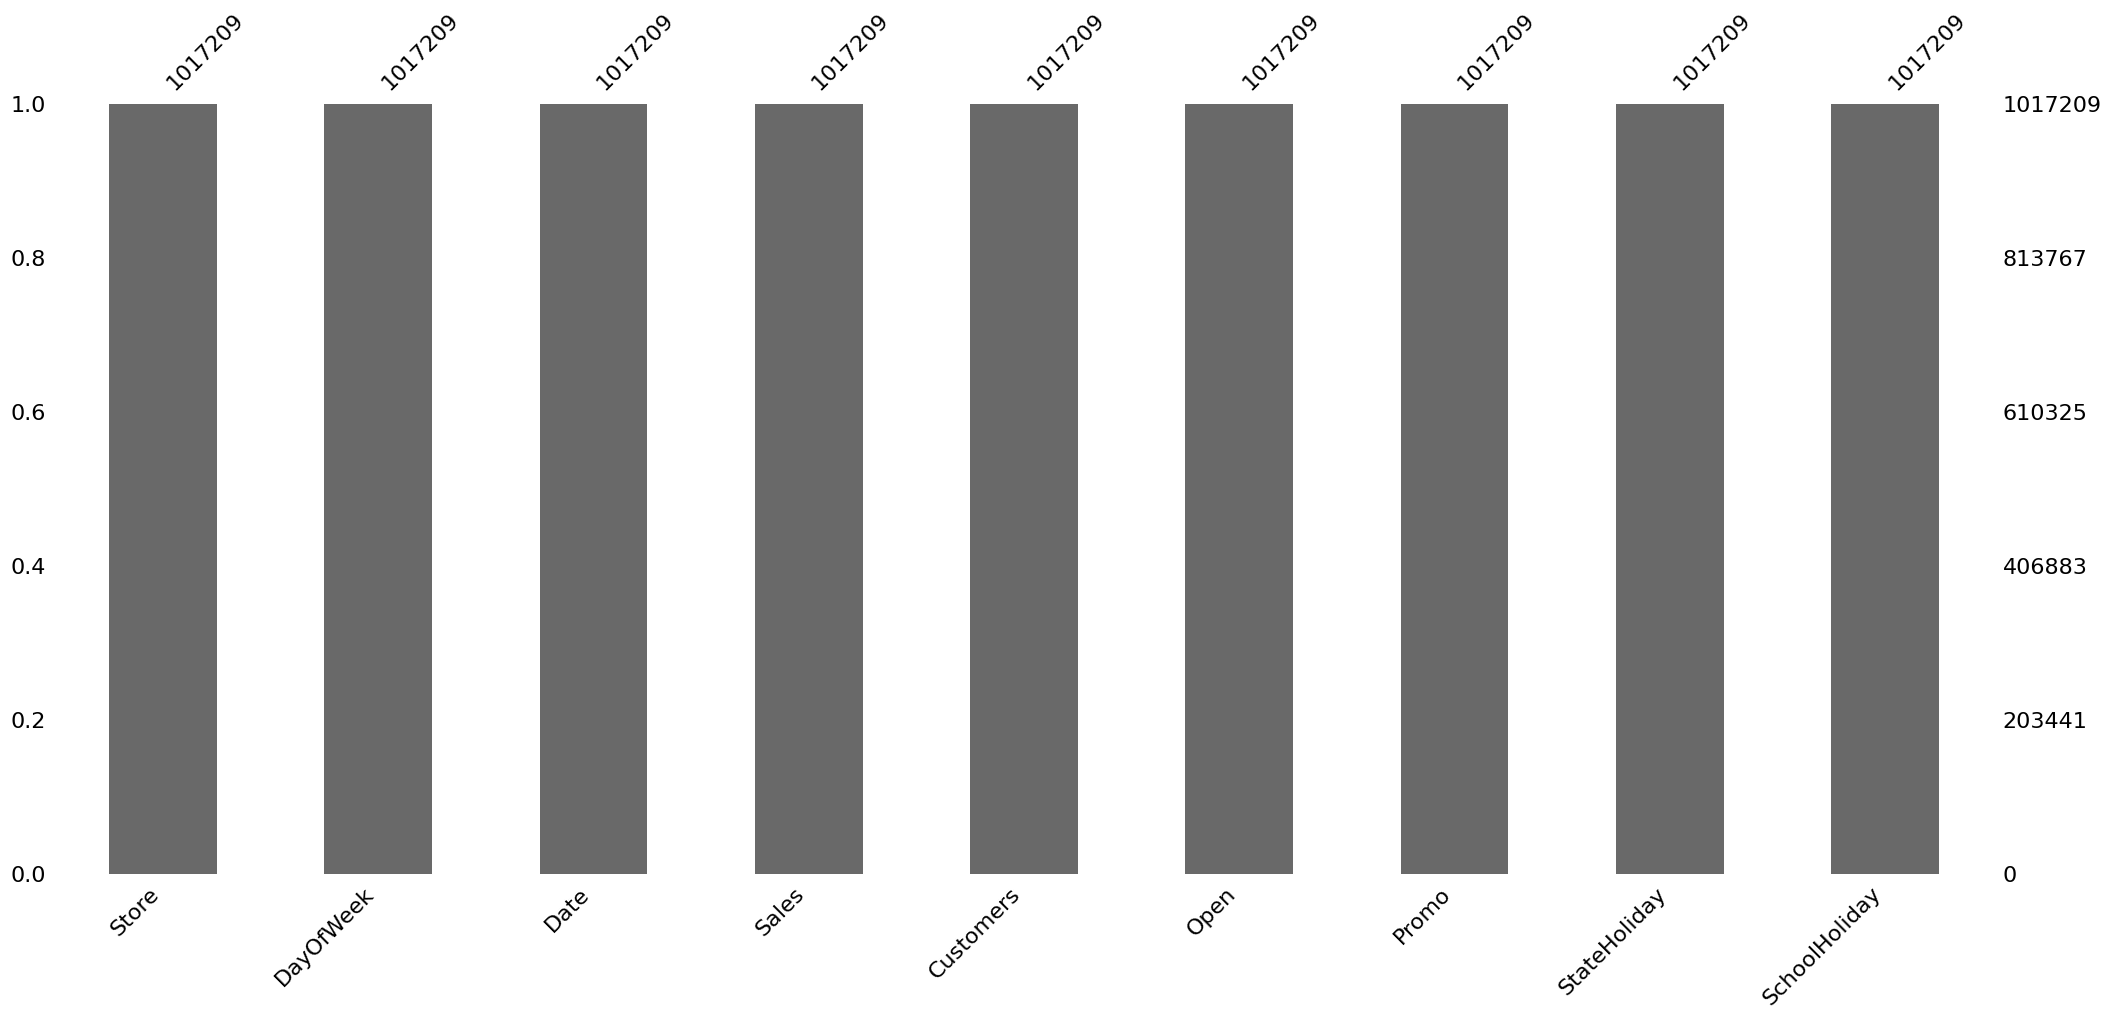

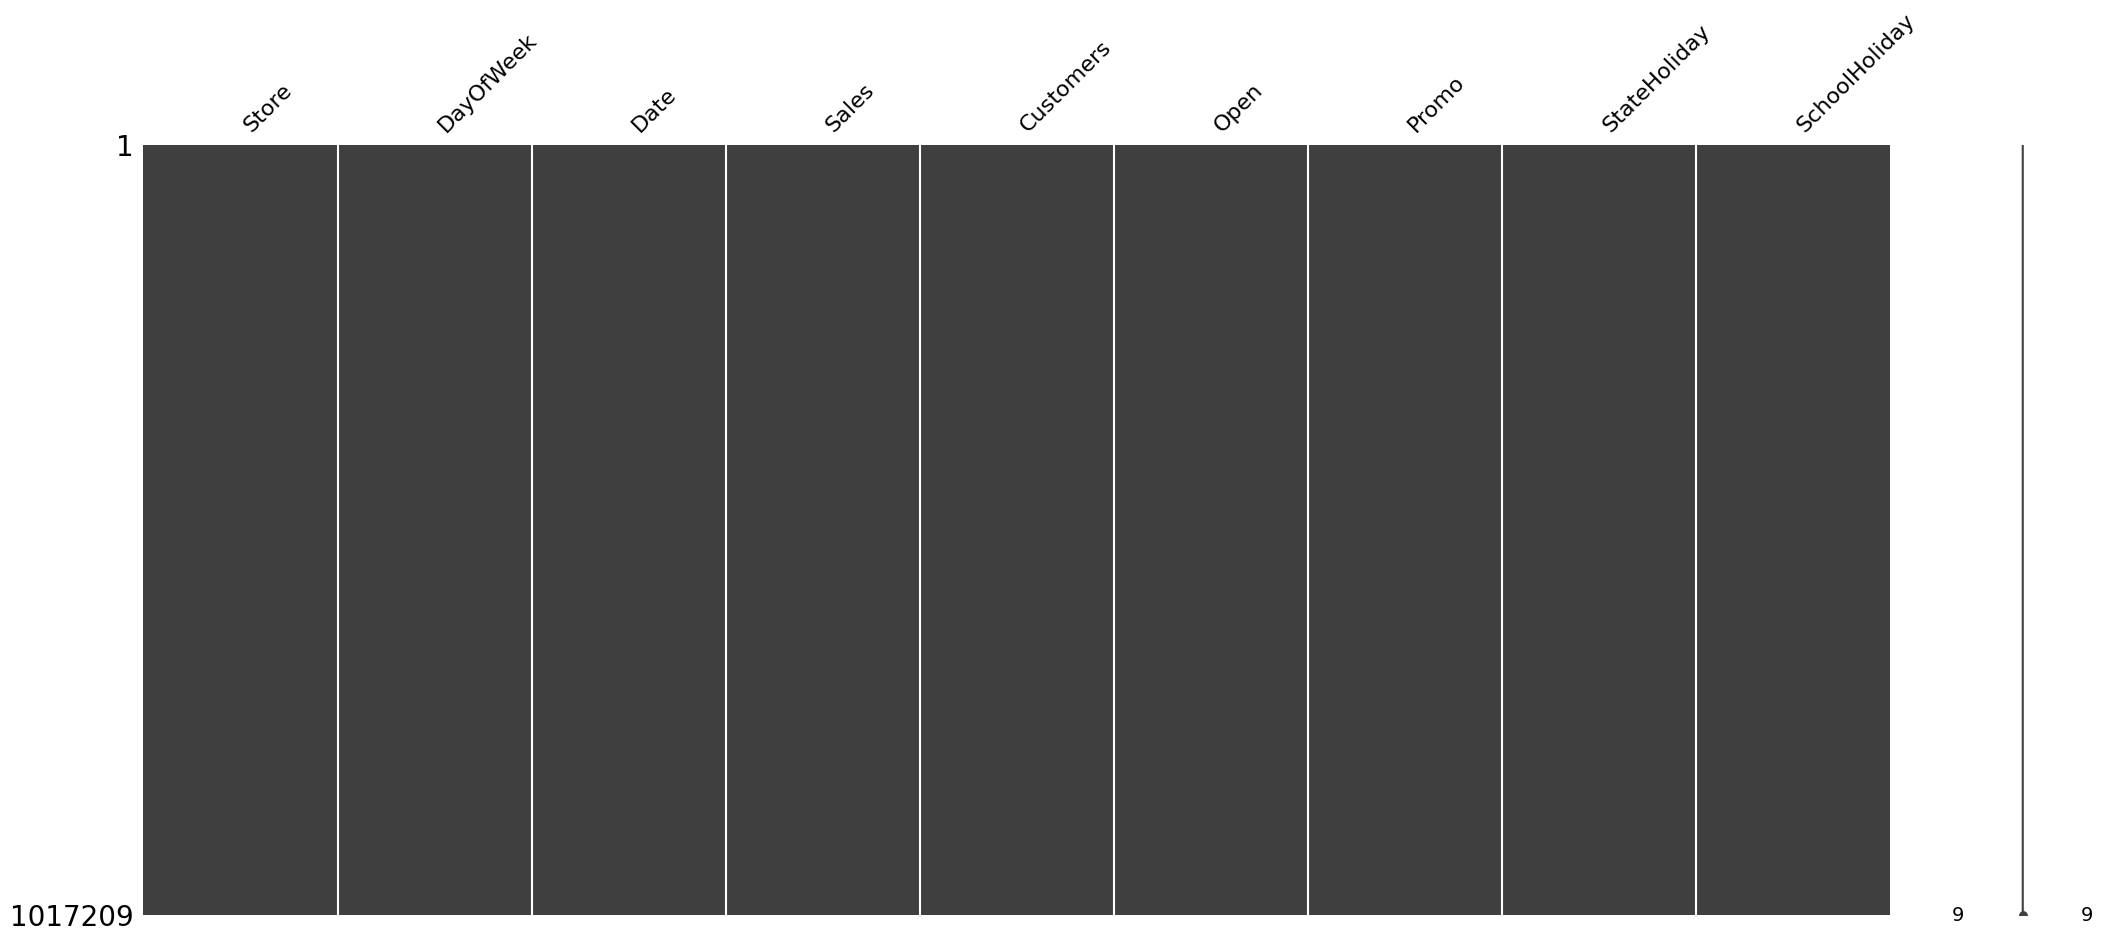

In [12]:
# Affichage du bar plot montrant le nombre de valeurs présentes et manquantes pour chaque colonne.
msno.bar(df)
plt.show()

# Affichage de la matrix plot montrant la densité et la position des valeurs manquantes.
msno.matrix(df)
plt.show()


In [13]:
# Number of each type of column
df.dtypes.value_counts()

int64     7
object    2
Name: count, dtype: int64

Affichage de la distribution de la cible:

Date
2013-01-01      97235
2013-01-02    6949829
2013-01-03    6347820
2013-01-04    6638954
2013-01-05    5951593
Name: Sales, dtype: int64


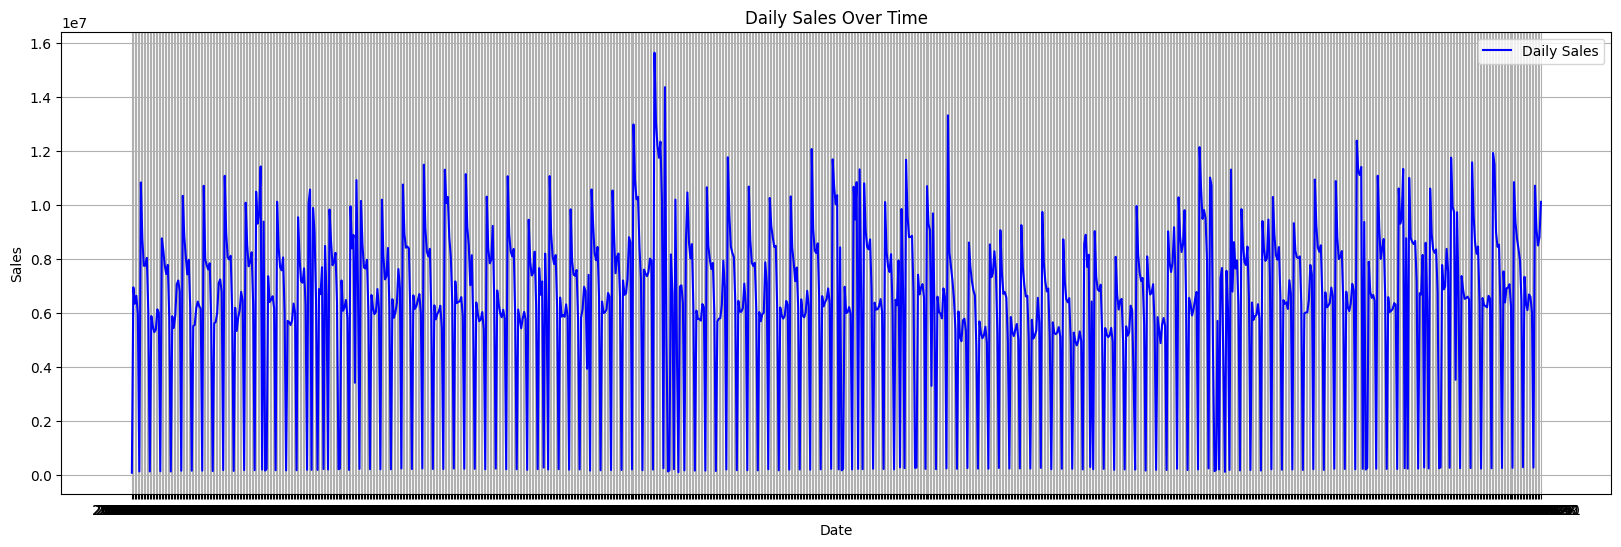

In [14]:
# Trier les dates pour éviter les désordres
df = df.sort_values("Date")

# Agréger les ventes par date
daily_sales = df.groupby("Date")["Sales"].sum()

# Afficher les 5 premières lignes
print(daily_sales.head())

# Tracer les ventes quotidiennes
plt.figure(figsize=(20, 6))
plt.plot(daily_sales, label="Daily Sales", color="blue")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Daily Sales Over Time")
plt.legend()
plt.grid()
plt.show()

In [15]:
print(df.dtypes)

Store             int64
DayOfWeek         int64
Date             object
Sales             int64
Customers         int64
Open              int64
Promo             int64
StateHoliday     object
SchoolHoliday     int64
dtype: object


In [16]:
# # Charger le fichier train.csv
# df = pd.read_csv(train_path, decimal=".",parse_dates=["Date"], low_memory=False)

# Vérifier si la colonne Date est bien en datetime
if not pd.api.types.is_datetime64_any_dtype(df["Date"]):
    df["Date"] = pd.to_datetime(df["Date"])

# Définir Date comme index
df.set_index("Date", inplace=True)

# Trier l'index
df = df.sort_index()


In [17]:
# Data extraction
df['Year'] = df.index.year
df['Month'] = df.index.month
df['DayOfMonth'] = df.index.day
df['DayOfYear'] = df.index.dayofyear  # Extrait le jour de l'année (1 à 365 ou 366)
df['WeekOfYear'] = df.index.isocalendar().week  # Extrait le numéro de la semaine ISO

# adding new variable
df['SalePerCustomer'] = df['Sales']/df['Customers']

df.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,DayOfMonth,DayOfYear,WeekOfYear,SalePerCustomer
Date,,,,,,,,,,,,,,
2013-01-01,1115,2,0,0,0,0,a,1,2013,1,1,1,1,NaN
2013-01-01,379,2,0,0,0,0,a,1,2013,1,1,1,1,NaN
2013-01-01,378,2,0,0,0,0,a,1,2013,1,1,1,1,NaN
2013-01-01,377,2,0,0,0,0,a,1,2013,1,1,1,1,NaN
2013-01-01,376,2,0,0,0,0,a,1,2013,1,1,1,1,NaN


In [18]:
df['SalePerCustomer'].describe()

count    844340.000000
mean          9.493619
std           2.197494
min           0.000000
25%           7.895563
50%           9.250000
75%          10.899729
max          64.957854
Name: SalePerCustomer, dtype: float64

Passons maintenant au fichier store.csv:
Pour rappel, description des colonnes du dataset, fournie sur Kaggle:

* Store: a unique Id for each store
* StoreType: differentiates between 4 different store models: a, b, c, d
* Assortment: describes an assortment level: a = basic, b = extra, c = extended
* CompetitionDistance: distance in meters to the nearest competitor store
* CompetitionOpenSince[Month/Year]: gives the approximate year and month of the time the nearest competitor was opened
* Promo2: Promo2 is a continuing a promotion for some stores: 0 = store is not participating, 1 = store is participating
* Promo2Since[Year/Week]: describes the year and calendar week when the store started participating in Promo2
* PromoInterval: describes the consecutive intervals Promo2 is started, naming the months the promotion is started. E.g. "Feb,May,Aug,Nov" means each * round starts in February, May, August, November of any given year for that store

In [19]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


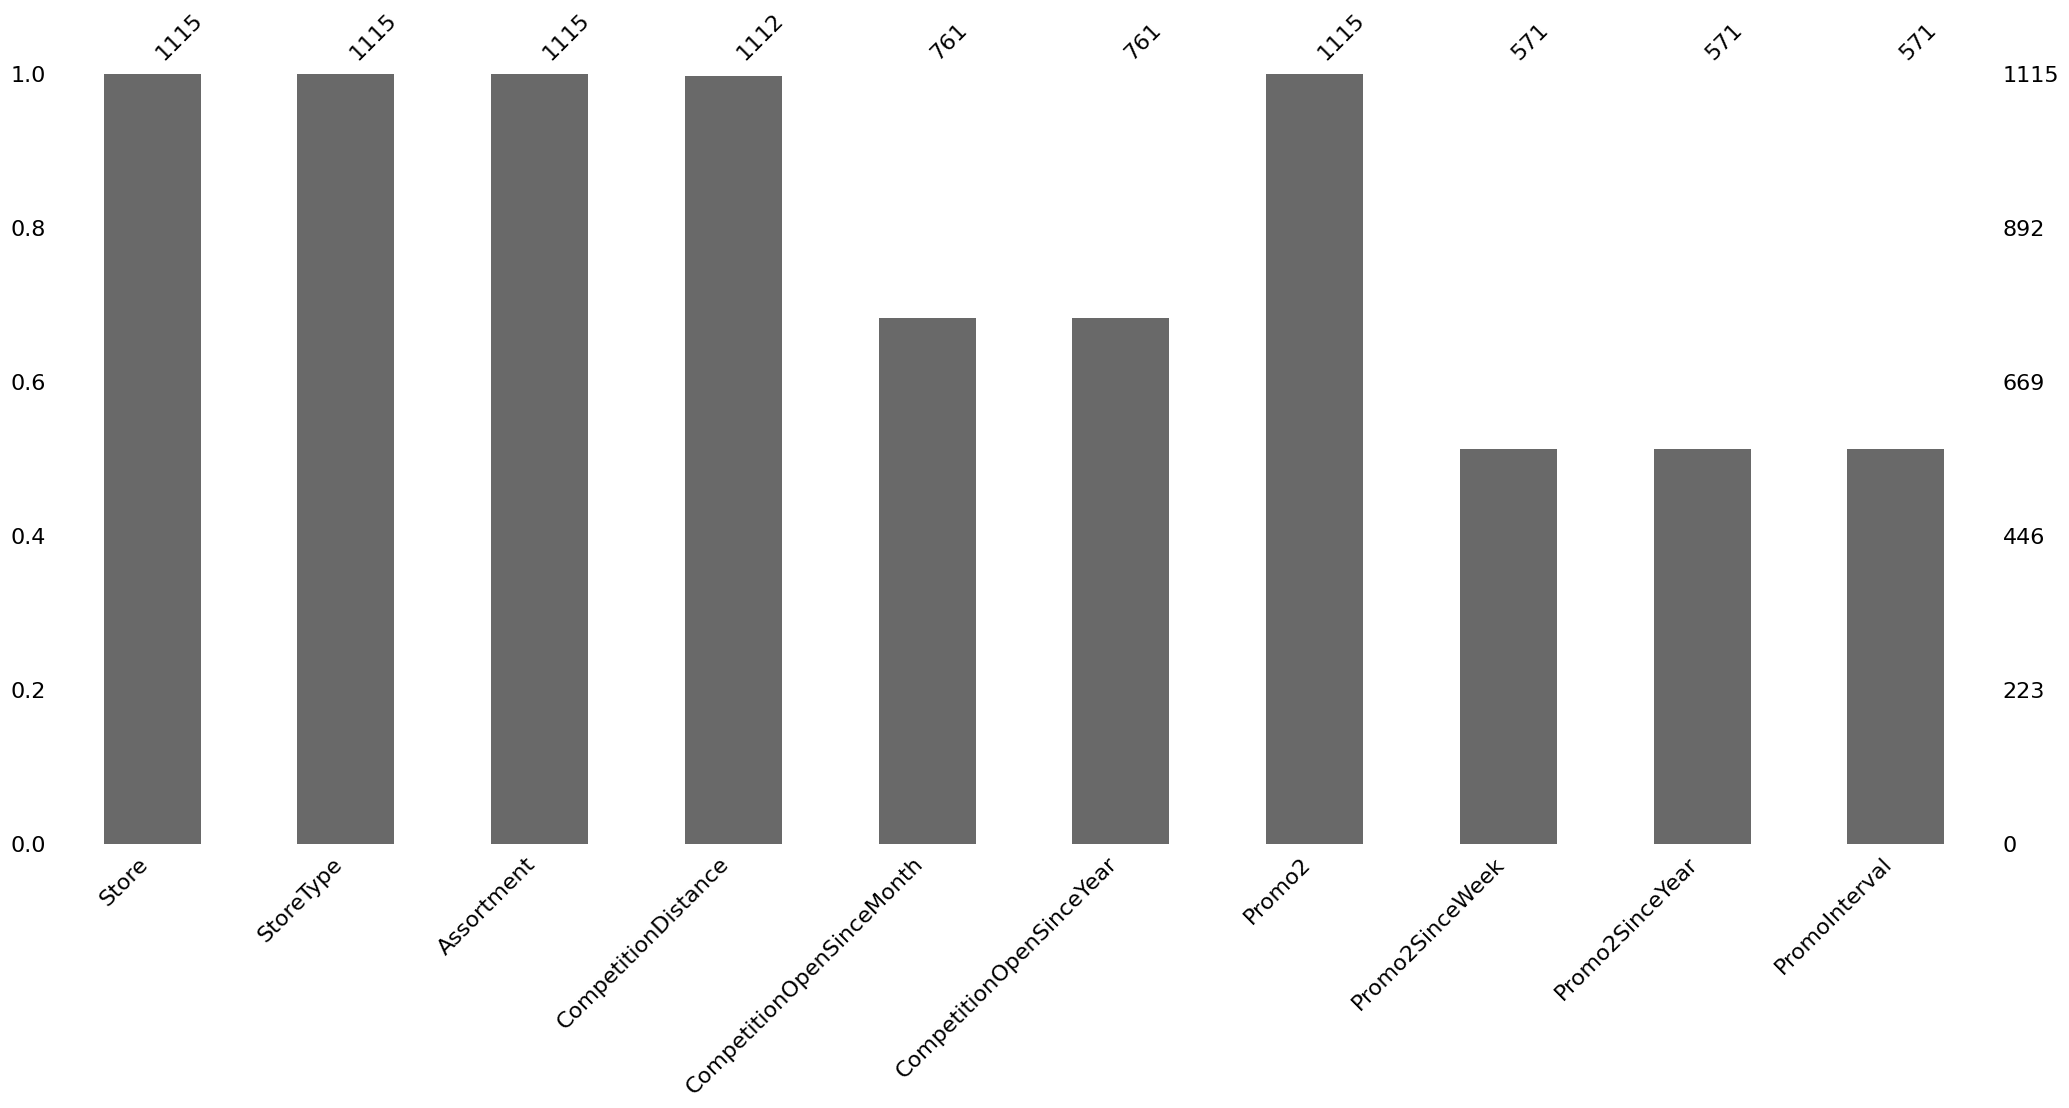

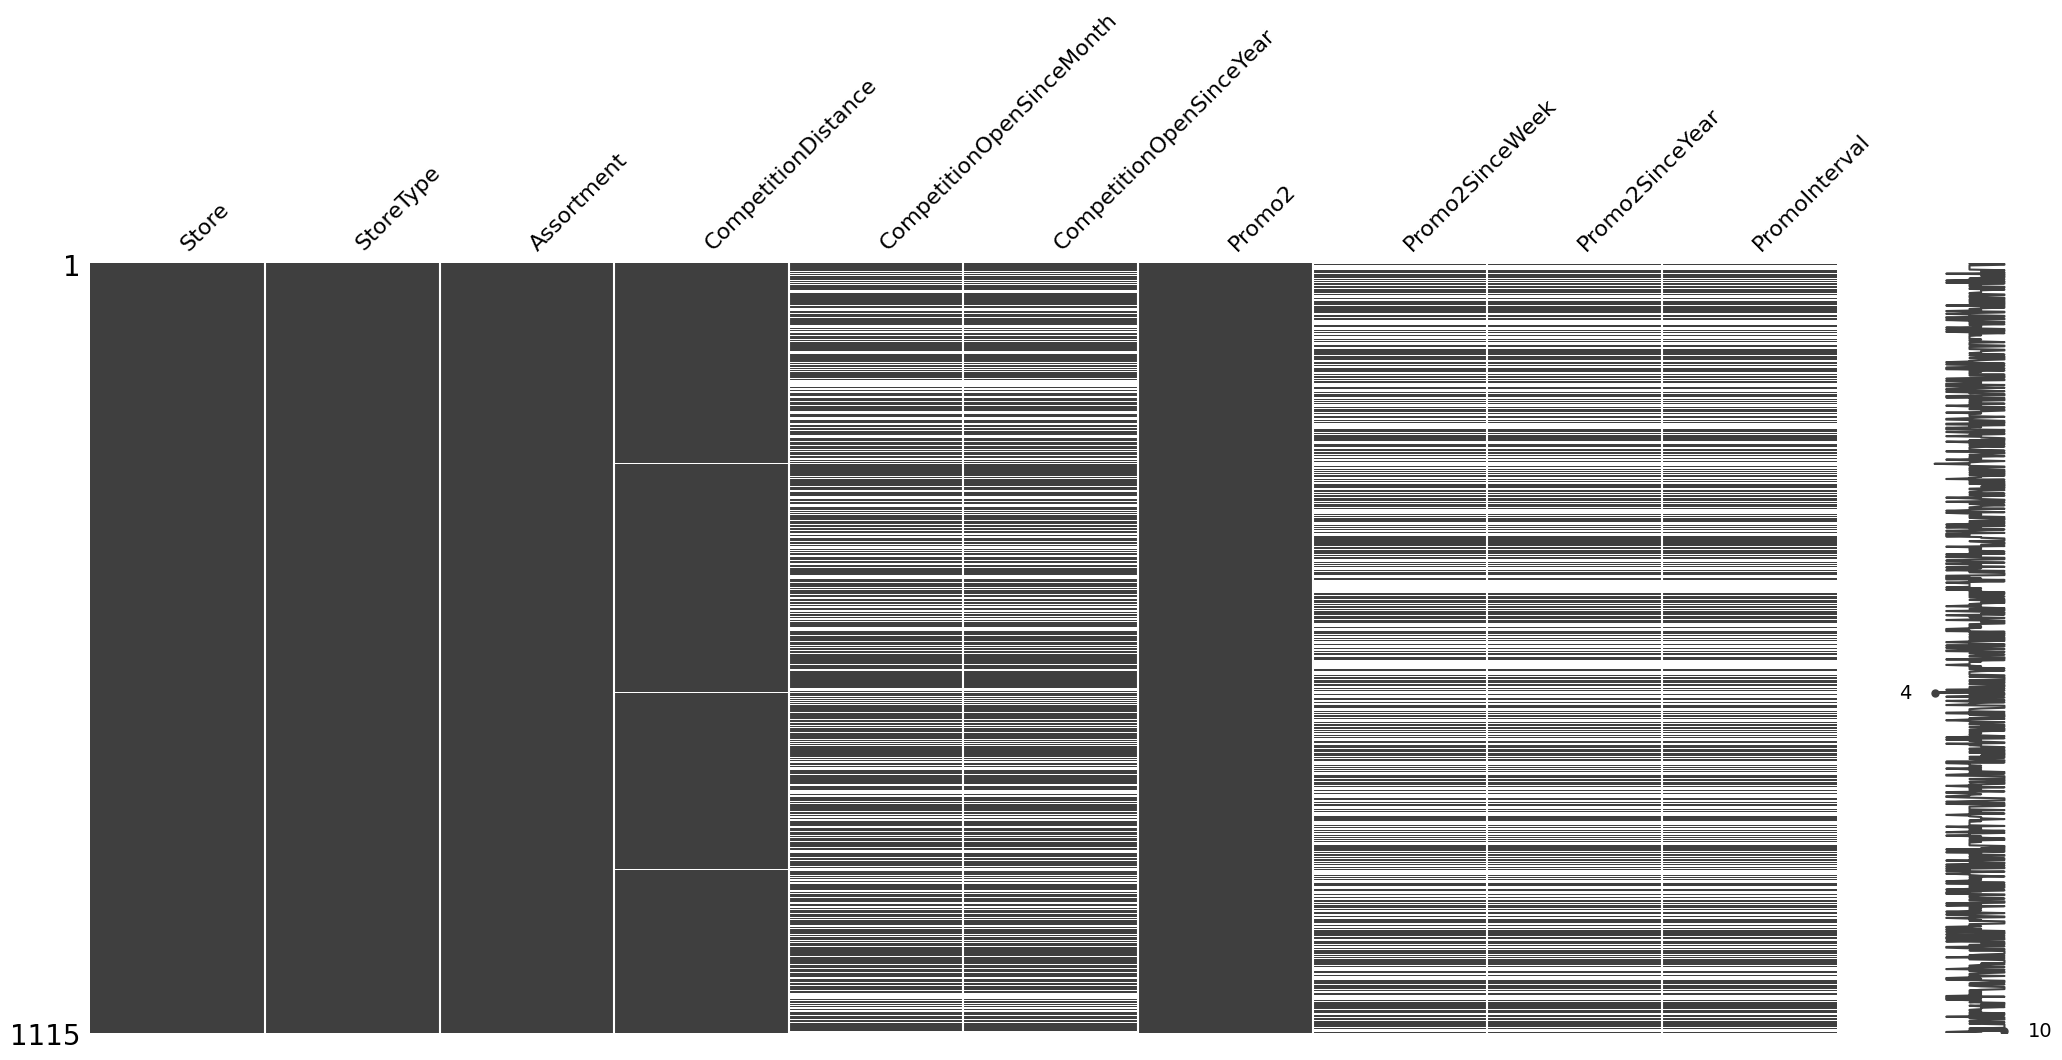

In [20]:
# Affichage du bar plot montrant le nombre de valeurs présentes et manquantes pour chaque colonne.
msno.bar(store)
plt.show()

# Affichage de la matrix plot montrant la densité et la position des valeurs manquantes.
msno.matrix(store)
plt.show()

In [21]:
# missing values?
store.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [22]:
df.reset_index(inplace=True)  # Réinitialiser l'index et restaurer la colonne 'Date'

# by specifying inner join we make sure that only those observations 
# that are present in both train and store sets are merged together
df = pd.merge(df, store, how = 'inner', on = 'Store')

print("In total: ", df.shape)
df.head()

In total:  (1017209, 24)


,Date,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,DayOfMonth,DayOfYear,WeekOfYear,SalePerCustomer,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,2013-01-01,1115,2,0,0,0,0,a,1,2013,1,1,1,1,NaN,d,c,5350.0,NaN,NaN,1,22.0,2012.0,"Mar,Jun,Sept,Dec"
1,2013-01-01,379,2,0,0,0,0,a,1,2013,1,1,1,1,NaN,d,a,6630.0,NaN,NaN,0,NaN,NaN,NaN
2,2013-01-01,378,2,0,0,0,0,a,1,2013,1,1,1,1,NaN,a,c,2140.0,8.0,2012.0,0,NaN,NaN,NaN
3,2013-01-01,377,2,0,0,0,0,a,1,2013,1,1,1,1,NaN,a,c,100.0,6.0,2010.0,1,18.0,2010.0,"Feb,May,Aug,Nov"
4,2013-01-01,376,2,0,0,0,0,a,1,2013,1,1,1,1,NaN,a,a,160.0,8.0,2012.0,0,NaN,NaN,NaN


# 3. Nettoyage et filtrage des données

## 3.1 Traitement des valeurs aberrantes

In [23]:
round(df.describe(),2)

,Date,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,Year,Month,DayOfMonth,DayOfYear,WeekOfYear,SalePerCustomer,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1017209,1017209.00,1017209.0,1017209.00,1017209.00,1017209.00,1017209.00,1017209.00,1017209.00,1017209.00,1017209.00,1017209.00,1017209.0,844340.00,1014567.00,693861.00,693861.00,1017209.0,509178.00,509178.00
mean,2014-04-11 01:30:42.846062080,558.43,4.0,5773.82,633.15,0.83,0.38,0.18,2013.83,5.85,15.70,162.28,23.62,9.49,5430.09,7.22,2008.69,0.5,23.27,2011.75
min,2013-01-01 00:00:00,1.00,1.0,0.00,0.00,0.00,0.00,0.00,2013.00,1.00,1.00,1.00,1.0,0.00,20.00,1.00,1900.00,0.0,1.00,2009.00
25%,2013-08-17 00:00:00,280.00,2.0,3727.00,405.00,1.00,0.00,0.00,2013.00,3.00,8.00,77.00,11.0,7.90,710.00,4.00,2006.00,0.0,13.00,2011.00
50%,2014-04-02 00:00:00,558.00,4.0,5744.00,609.00,1.00,0.00,0.00,2014.00,6.00,16.00,153.00,22.0,9.25,2330.00,8.00,2010.00,1.0,22.00,2012.00
75%,2014-12-12 00:00:00,838.00,6.0,7856.00,837.00,1.00,1.00,0.00,2014.00,8.00,23.00,241.00,35.0,10.90,6890.00,10.00,2013.00,1.0,37.00,2013.00
max,2015-07-31 00:00:00,1115.00,7.0,41551.00,7388.00,1.00,1.00,1.00,2015.00,12.00,31.00,365.00,52.0,64.96,75860.00,12.00,2015.00,1.0,50.00,2015.00
std,NaN,321.91,2.0,3849.93,464.41,0.38,0.49,0.38,0.78,3.33,8.79,101.62,14.43,2.20,7715.32,3.21,5.99,0.5,14.10,1.66


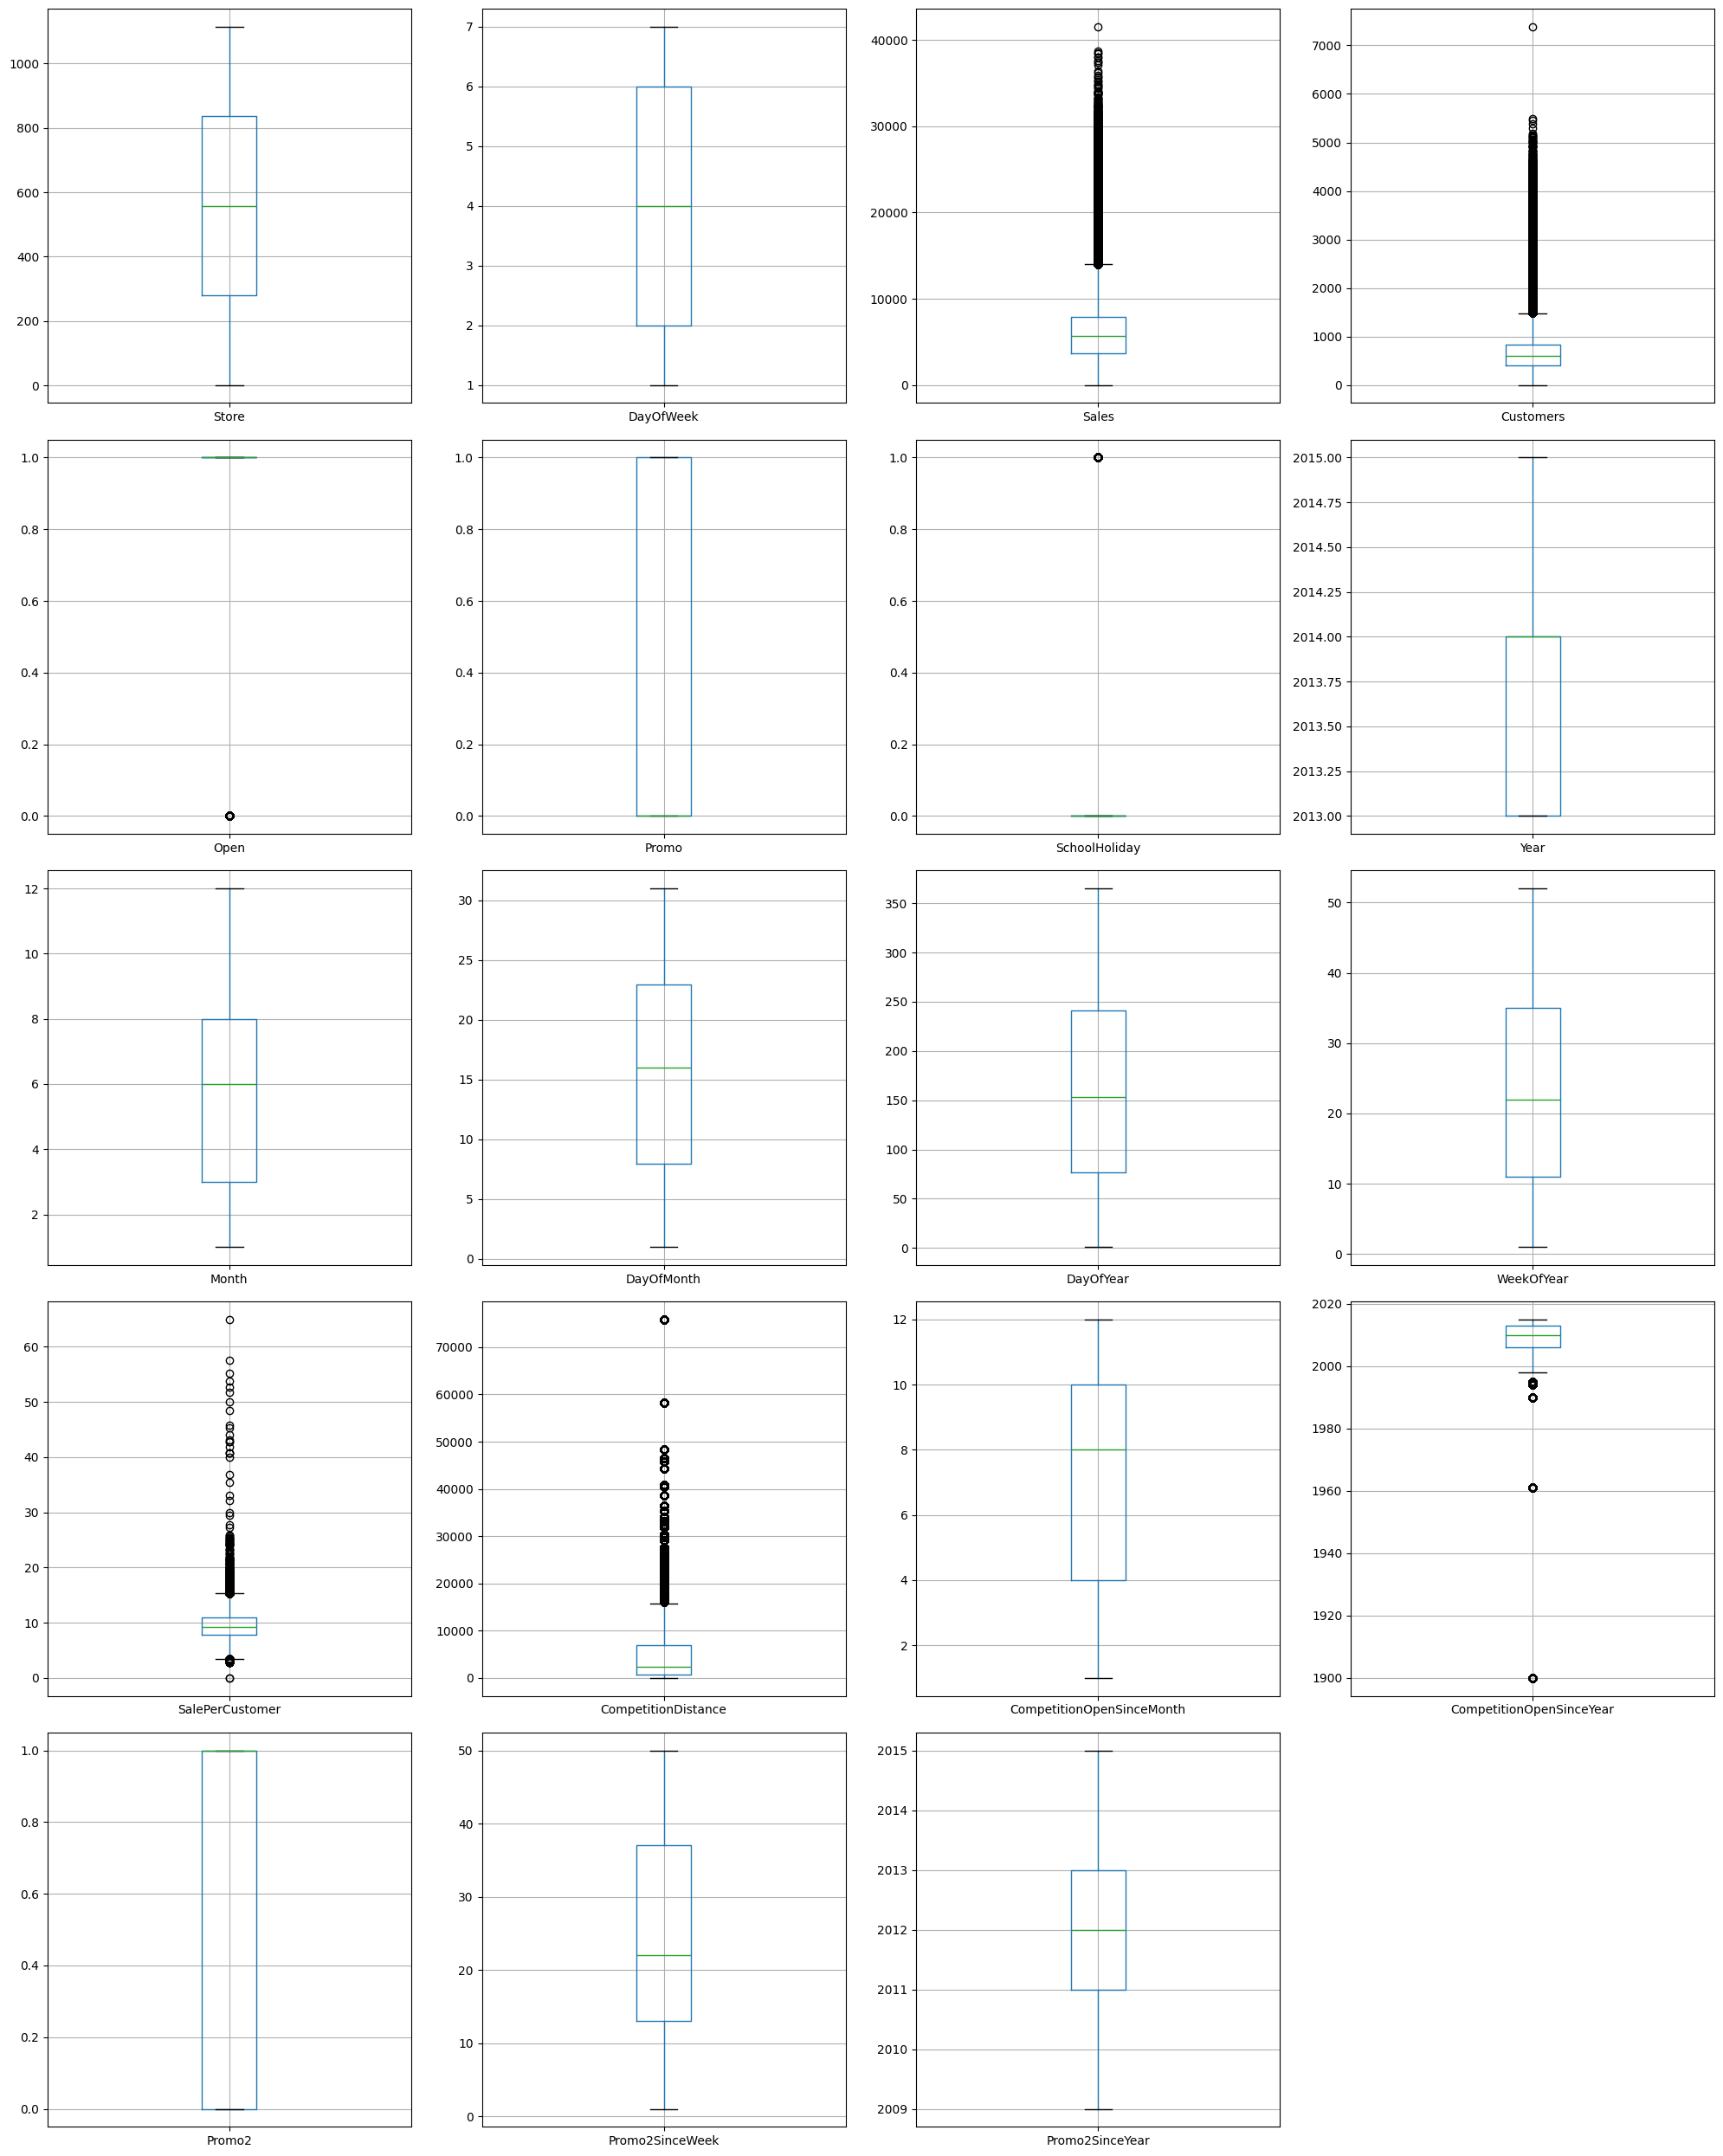

In [24]:
numerical_columns = df.select_dtypes(include=['number']).columns

# Ajuster la taille de la figure en fonction du nombre de colonnes valides
num_features = len(numerical_columns)
num_cols = 4
num_rows = -(-num_features // num_cols)

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(num_cols * 5, num_rows * 5))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    df.boxplot(column=col, ax=axes[i])

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


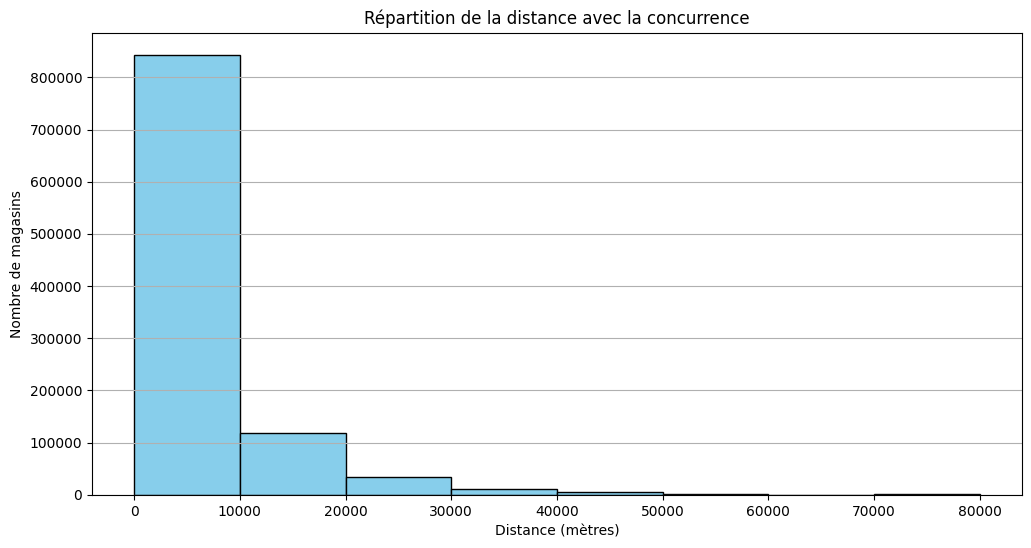

In [25]:
# Définir les bins (0, 10k, 20k, ..., 80k)
bins = np.arange(0, 90000, 10000)

# Histogramme
plt.figure(figsize=(12, 6))
plt.hist(df["CompetitionDistance"].dropna(), bins=bins, edgecolor='black', color='skyblue')
plt.title("Répartition de la distance avec la concurrence")
plt.xlabel("Distance (mètres)")
plt.ylabel("Nombre de magasins")
plt.xticks(bins)
plt.grid(axis="y")
plt.show()

In [26]:
col_quanti =['CompetitionDistance']

count_outliers = 0


for col in col_quanti:

    #Calcul des quantiles, interquantiles et seuils min/max pour définir les outliers :

    q1 =  df[col].quantile(0.25) #Calcul du quantile Q1 (25%)
    q3 =  df[col].quantile(0.75) #Calcul du quantile Q3 (75%)     
    iq = q3-q1 #calcul de l'interquartile
    mediane = df[col].median()
    
    seuilMin = max(q1-1.5*iq,0)      # calcul de la valeur min de la moustache, toute valeur inferieure est considérée comme outlier
    seuilMax = q3+1.5*iq #calcul de la valeur max de la moustache, toute valeur superieure est considérée comme outlier

    # Mask pour definir un outlier pour chaque groupe de produit
    mask = (df[col] < seuilMin) | (df[col] > seuilMax)
    
    # Comptage des outliers en dehors des seuils Min et Max
    count_outliers += mask.sum()
    
    #remplacement des outliers en dehors des seuils Min et Max par la mediane de chaque groupe
    df.loc[mask, col] = seuilMax

print(f"Nombre d'outliers remplacés par un seuil max: {count_outliers}")

Nombre d'outliers remplacés par un seuil max: 99160


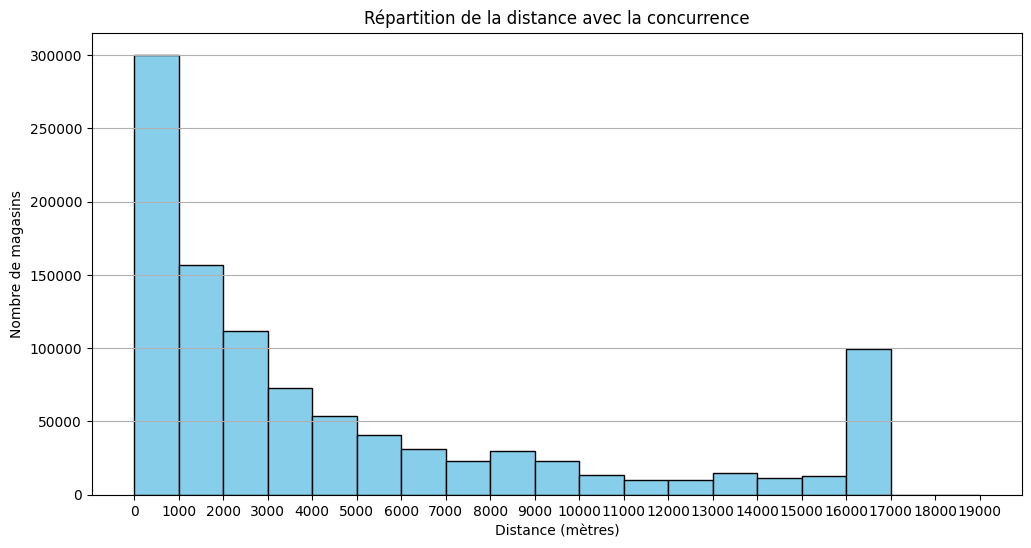

In [27]:
# Définir les bins (0, 10k, 20k, ..., 80k)
bins = np.arange(0, 20000, 1000)

# Histogramme
plt.figure(figsize=(12, 6))
plt.hist(df["CompetitionDistance"].dropna(), bins=bins, edgecolor='black', color='skyblue')
plt.title("Répartition de la distance avec la concurrence")
plt.xlabel("Distance (mètres)")
plt.ylabel("Nombre de magasins")
plt.xticks(bins)
plt.grid(axis="y")
plt.show()

## 3.2. Traitement des valeurs manquantes

Rappel par colonne des valeurs manquantes:

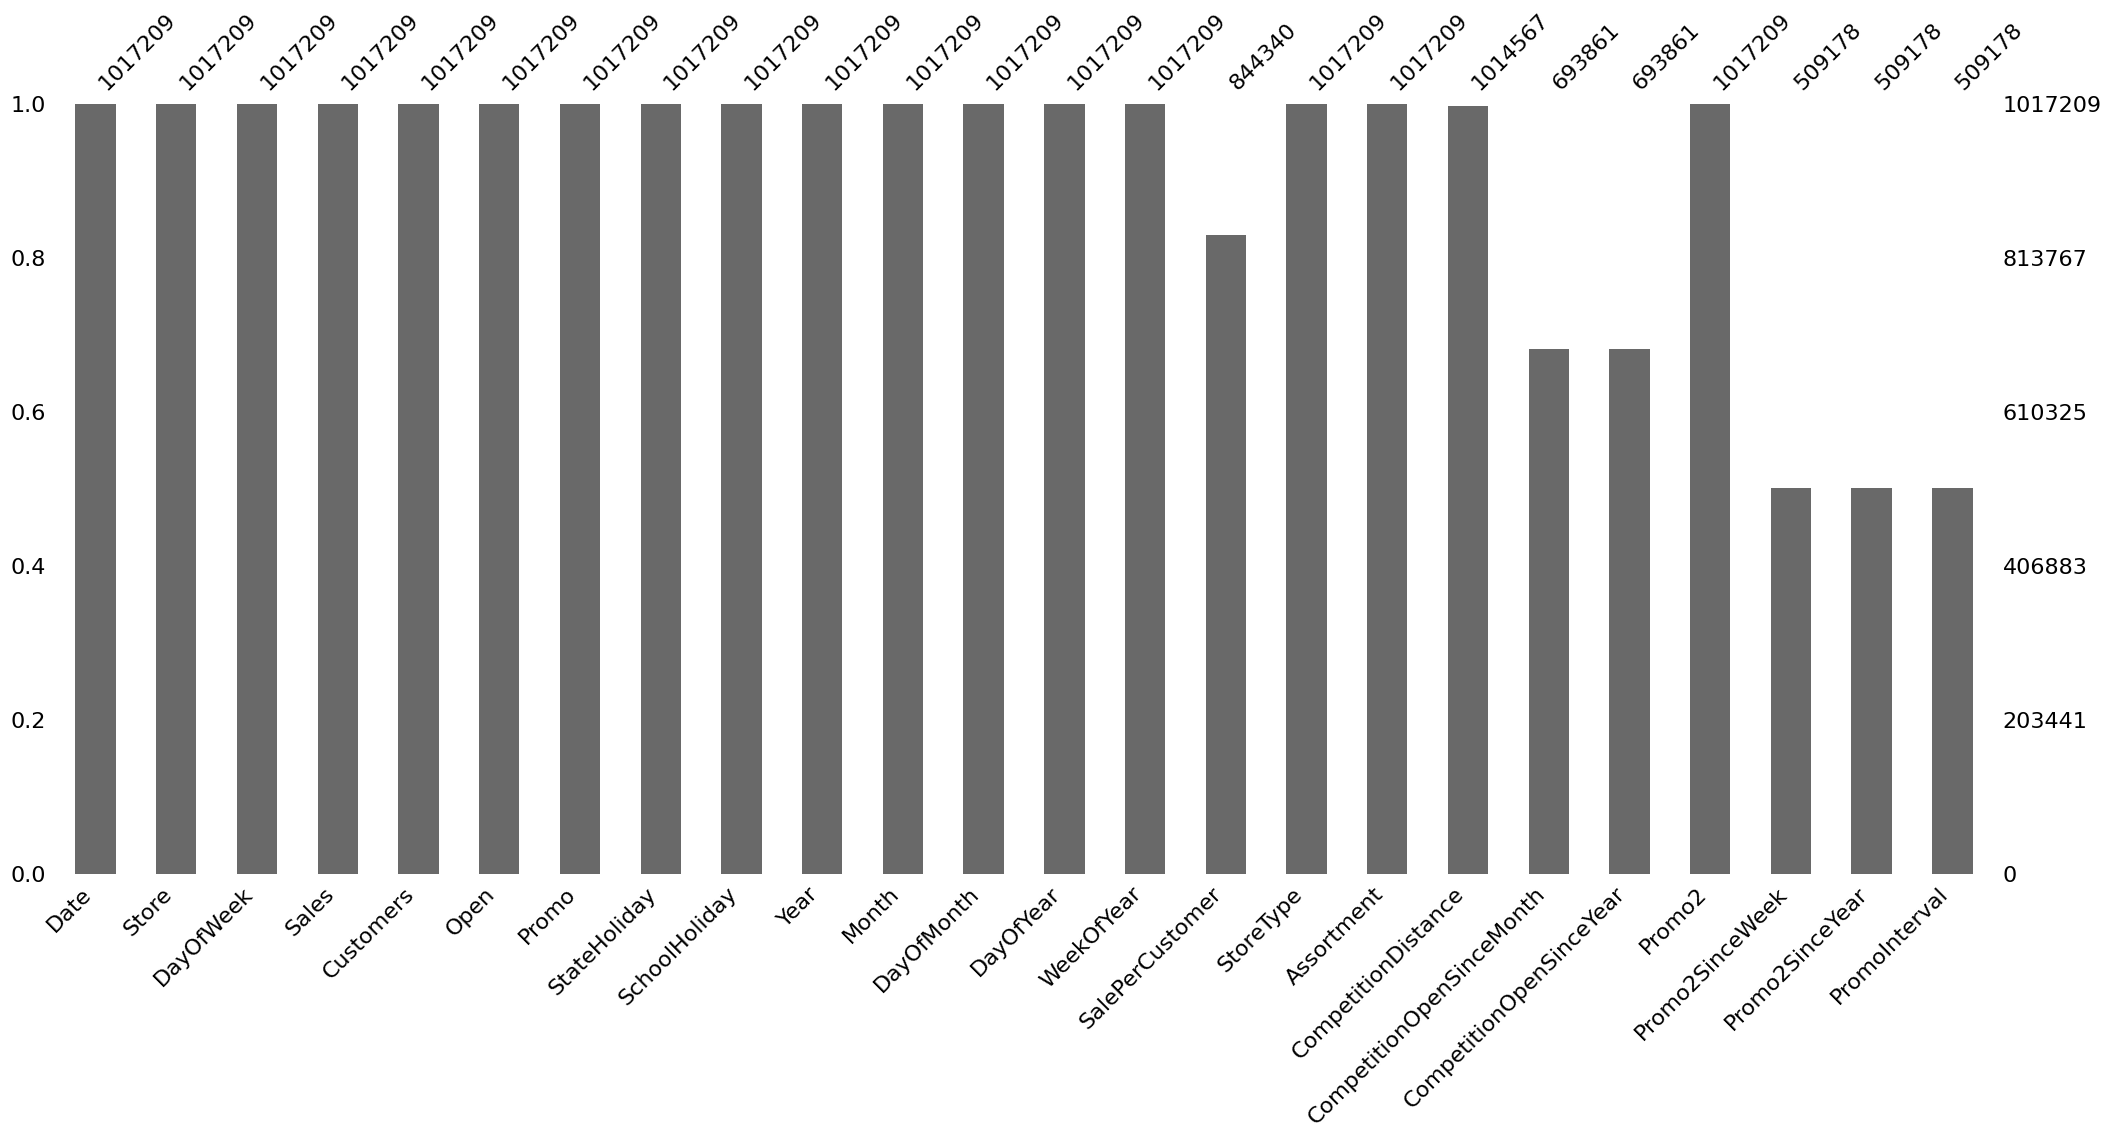

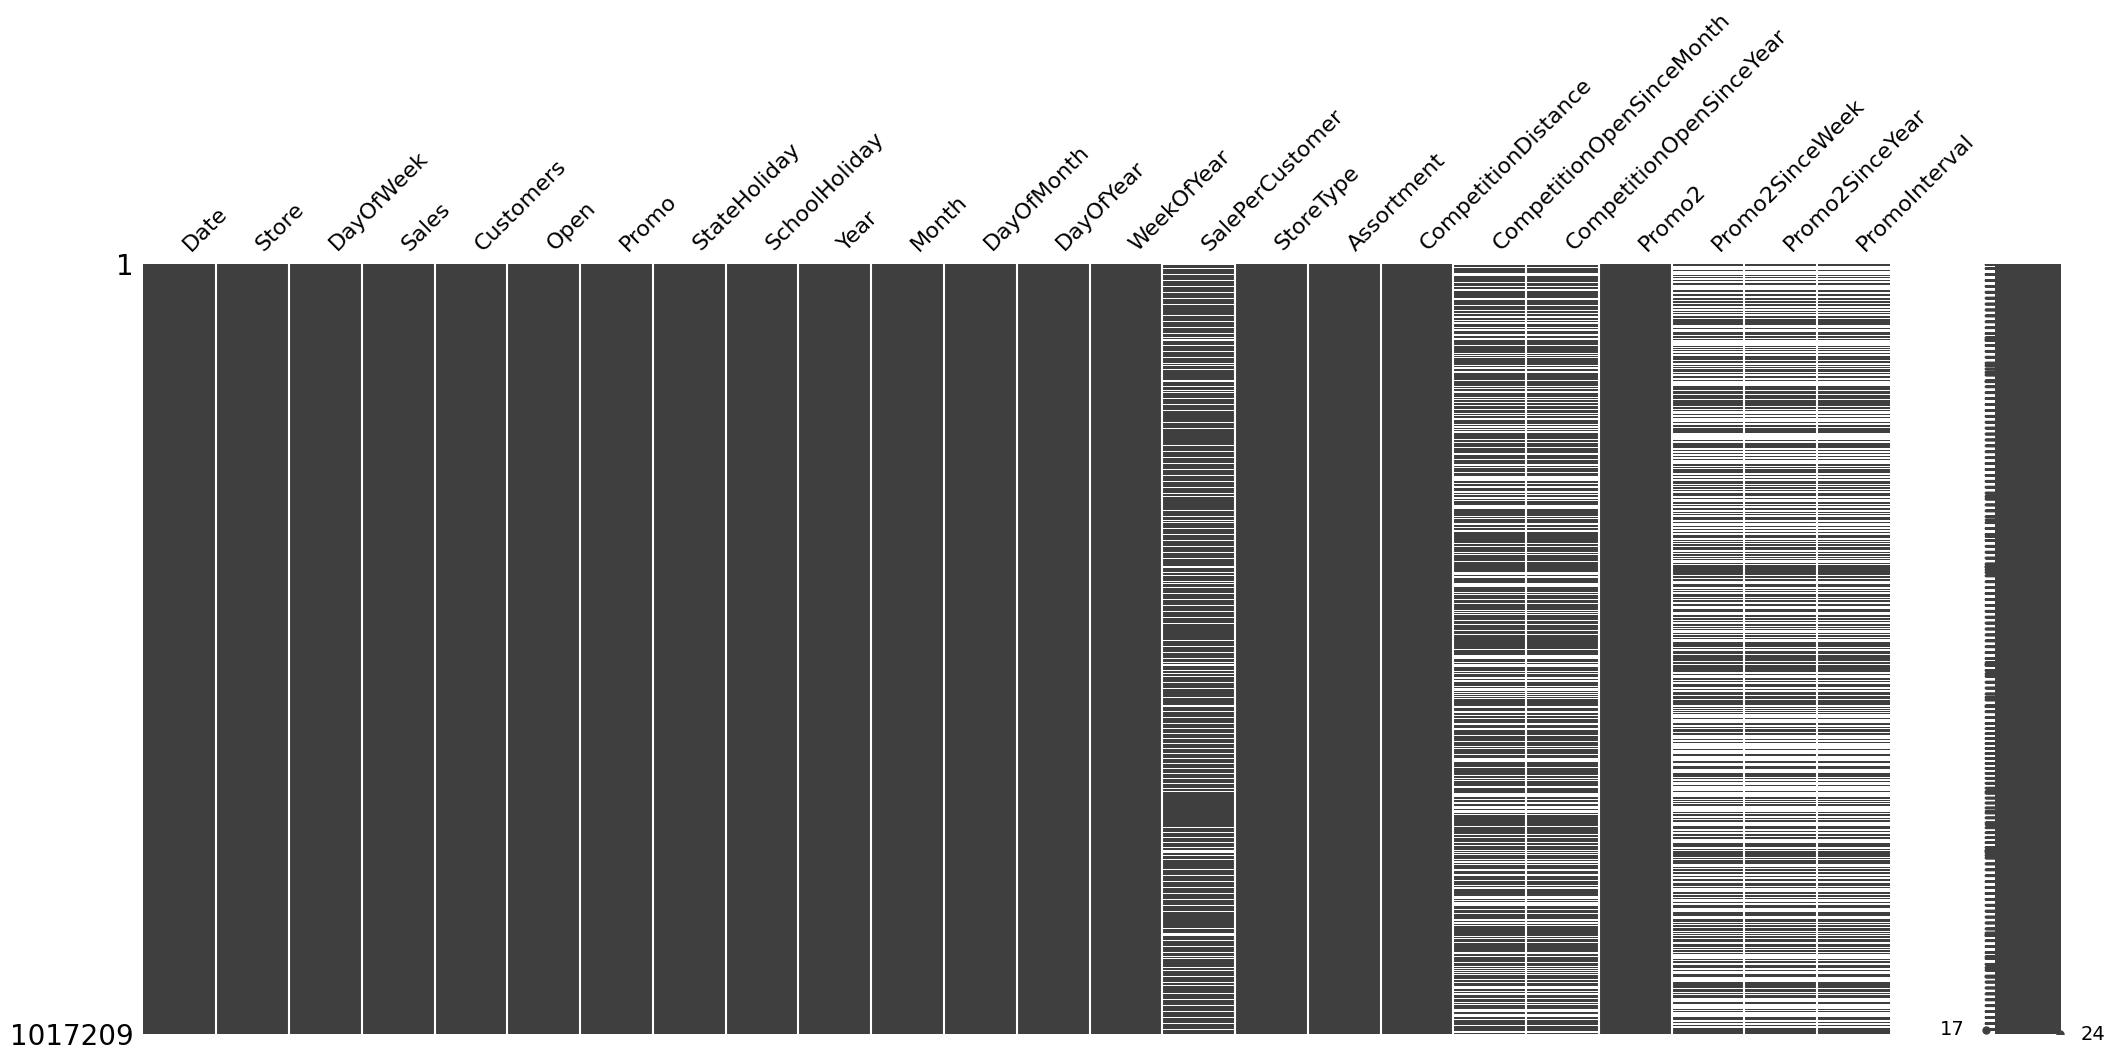

In [28]:
# Affichage du bar plot montrant le nombre de valeurs présentes et manquantes pour chaque colonne.
msno.bar(df)
plt.show()

# Affichage de la matrix plot montrant la densité et la position des valeurs manquantes.
msno.matrix(df)
plt.show()

In [29]:
# Remplacer les valeurs NaN par 0
df['SalePerCustomer'] = df['SalePerCustomer'].fillna(0)

# Remplacer les valeurs NaN par un flag"No_Promo2"
df['PromoInterval'] = df['PromoInterval'].fillna('No_Promo2')

## 3.3 Suppression des colonnes inutiles

Nous allons supprimer les colonnes suivant plusieurs cirtères:
> - les colonnes qui n'ont pas ou très peu de corrélation avec la target (Sales)
> - les colonnes qui ont des informations redondantes entre elles
> - les colonnes qui n'auront pas d'impact sur les prévisions

Cherchons d'abord les correlations avec la target pour supprimmer les colonnes qui n'ont pas de corrélation avec la target;

In [30]:
# Filtre sur les colonnes numériques
numeric_cols = df.select_dtypes(include=['number'])

# calcul des correlations de chaque feature avec la target:
correlations = round(numeric_cols.corr()['Sales'].abs()*100,2).sort_values(ascending=False)


#Affichage
print('Affichage du coefficient de corrélation de Pearson de chaque feature vs TARGET:')
correlations

Affichage du coefficient de corrélation de Pearson de chaque feature vs TARGET:


Sales                        100.00
Customers                     89.47
Open                          67.85
SalePerCustomer               65.88
DayOfWeek                     46.21
Promo                         45.23
Promo2                         9.10
SchoolHoliday                  8.51
Promo2SinceWeek                5.96
WeekOfYear                     5.29
Month                          4.88
DayOfYear                      4.75
CompetitionOpenSinceMonth      2.83
CompetitionDistance            2.57
Year                           2.35
Promo2SinceYear                2.11
CompetitionOpenSinceYear       1.27
DayOfMonth                     1.16
Store                          0.51
Name: Sales, dtype: float64

In [31]:
cols_to_drop = {'Promo2SinceWeek','Promo2SinceYear','CompetitionOpenSinceYear','CompetitionOpenSinceMonth'}

Avant de supprimmer les colonnes 'CompetitionOpenSinceYear','CompetitionOpenSinceMonth', on va les remplacer par un flag CompetitionActive

In [32]:
def is_competition_active(row):
    """
    Détermine si la compétition est active à la date donnée.
    - Retourne 1 si la compétition a commencé, 0 sinon.
    """
    if pd.isna(row["CompetitionOpenSinceYear"]) or pd.isna(row["CompetitionOpenSinceMonth"]):
        return 0
    
    comp_start = pd.Timestamp(year=int(row["CompetitionOpenSinceYear"]),
                               month=int(row["CompetitionOpenSinceMonth"]),
                               day=1)
    
    # Convert row.name (index) to Timestamp
    row_date = pd.Timestamp(row.name)
    
    return 1 if row_date >= comp_start else 0

# Application
df["CompetitionActive"] = df.apply(is_competition_active, axis=1)

In [33]:
# def is_competition_active(row):
#     """
#     Détermine si la compétition est active à la date donnée.
#     - Retourne 1 si la compétition a commencé, 0 sinon.
#     """
#     if pd.isna(row["CompetitionOpenSinceYear"]) or pd.isna(row["CompetitionOpenSinceMonth"]):
#         return 0

#     comp_start = pd.Timestamp(year=int(row["CompetitionOpenSinceYear"]), 
#                               month=int(row["CompetitionOpenSinceMonth"]), 
#                               day=1)
#     return 1 if row.name >= comp_start else 0  # row.name = index = date

# # Application
# df["CompetitionActive"] = df.apply(is_competition_active, axis=1)

In [34]:
def is_promo2_active(row, hypothesis="full_month"):
    """
    Détermine si un jour donné est sous Promo2 selon l'hypothèse choisie.
    
    Args:
    - row: une ligne du DataFrame
    - hypothesis: "full_month" (promo dure tout le mois) ou "first_week" (promo dure 7 jours)
    
    Returns:
    - 1 si Promo2 est actif, 0 sinon
    """
    # Si le magasin est fermé, la promo est inactive
    if row["Open"] == 0:
        return 0  
    
    if row["Promo2"] == 0 or pd.isna(row["PromoInterval"]):
        return 0  # Le magasin ne participe pas à Promo2

     # Convertir PromoInterval en liste de mois
    promo_months = row["PromoInterval"].split(",")  # Ex: "Feb,May,Aug,Nov" → ["Feb", "May", "Aug", "Nov"]
    # Récupérer l'année et la semaine de début de Promo2
    
    promo_start_year = row["Promo2SinceYear"]
    promo_start_week = row["Promo2SinceWeek"]

    # Vérifier que la date actuelle est après le début de Promo2
    if (row["Year"] < promo_start_year) or (row["Year"] == promo_start_year and row["WeekOfYear"] < promo_start_week):
        return 0  

    # Vérifier si le mois en cours est dans les mois de Promo2
    current_month_name = row["Date"].strftime("%b")  
    if current_month_name in promo_months:
        if hypothesis == "full_month":
            return 1
        elif hypothesis == "first_week":
            return 1 if row["DayOfMonth"] <= 7 else 0 # Promo active seulement la première semaine

    return 0  # Promo non active

# Appliquer aux données
df["Promo2Active"] = df.apply(lambda row: is_promo2_active(row, hypothesis="full_month"), axis=1)

# df["Promo2Active"] = df.apply(lambda row: is_promo2_active(row, hypothesis="first_week"), axis=1)  # Si on veut tester l'autre hypothèse


In [35]:
# on défini les précédentes listes créées comme des ensembles
cols_to_drop = set(cols_to_drop)

# Affichage des résultats
print(f" {len(cols_to_drop)} vont être supprimées:")
print(cols_to_drop)

 4 vont être supprimées:
{'CompetitionOpenSinceYear', 'Promo2SinceWeek', 'CompetitionOpenSinceMonth', 'Promo2SinceYear'}


Suppression de ces colonnes du DataFrame

In [36]:
df = df.drop(columns=cols_to_drop)

# 4. Analyses uni et multi variées

## 4.1 Analyses uni-variées

### 4.1.1 Features catégorielles

In [37]:
#boucle pour afficher le résultat sur chacune des variables 
for var in df.select_dtypes('object'):
    
    # AFfichage d'un top 10 avec ses nb d'occurences et fréquences
    effectifs = df[var].value_counts()
    modalites = effectifs.index
    
    tableau = pd.DataFrame(modalites, columns = [var]) 
    tableau['nb'] = effectifs.values  #création d'une colonne qui affiche le nombre d'occurences
    tableau['frequence(%)'] = (tableau['nb'] / len(df)*100).round(2) #création d'une colonne qui affiche la fréquence

    # Grouper les données par la variable et la cible (Sales) et calculer le nombre de valeurs
    grouped = df.groupby([var, 'Sales']).size().unstack().fillna(0)
    
    # # Calculer le pourcentage de classe 1 fccpour chaque entité
    # percent_target_1 = (grouped[1] / grouped.sum(axis=1)) * 100
    
    # # Ajouter la colonne '% de Cible=1' au tableau
    # tableau = tableau.merge(percent_target_1.round(2).rename('Cible (%)'), left_on=var, right_index=True, how='left')
    

    # Afficher le top 10 des modalités en termes d'occurrences
    print("\n", tableau.sort_values('nb', ascending=False).head(10))
    print()


   StateHoliday      nb  frequence(%)
0            0  986159         96.95
1            a   20260          1.99
2            b    6690          0.66
3            c    4100          0.40


   StoreType      nb  frequence(%)
0         a  551627         54.23
1         d  312912         30.76
2         c  136840         13.45
3         b   15830          1.56


   Assortment      nb  frequence(%)
0          a  537445         52.84
1          c  471470         46.35
2          b    8294          0.82


       PromoInterval      nb  frequence(%)
0         No_Promo2  508031         49.94
1   Jan,Apr,Jul,Oct  293122         28.82
2   Feb,May,Aug,Nov  118596         11.66
3  Mar,Jun,Sept,Dec   97460          9.58



### 4.1.2 Features quantitatives

Affichages des caractéristiques des features quantitatives via:

- le mode et asymetrie (Skewness):
- une courbe de densité
- un histogramme
- une boite a moustache

Store
Mesure d'asymetrie: -0.0

Sales
Mesure d'asymetrie: 0.64

Customers
Mesure d'asymetrie: 1.6

Open
Mesure d'asymetrie: -1.76

Promo
Mesure d'asymetrie: 0.49

SchoolHoliday
Mesure d'asymetrie: 1.68

DayOfMonth
Mesure d'asymetrie: 0.01

DayOfYear
Mesure d'asymetrie: 0.28

SalePerCustomer
Mesure d'asymetrie: -0.81

CompetitionDistance
Mesure d'asymetrie: 1.21

Promo2
Mesure d'asymetrie: -0.0

CompetitionActive
Mesure d'asymetrie: 24.4

Promo2Active
Mesure d'asymetrie: 2.34



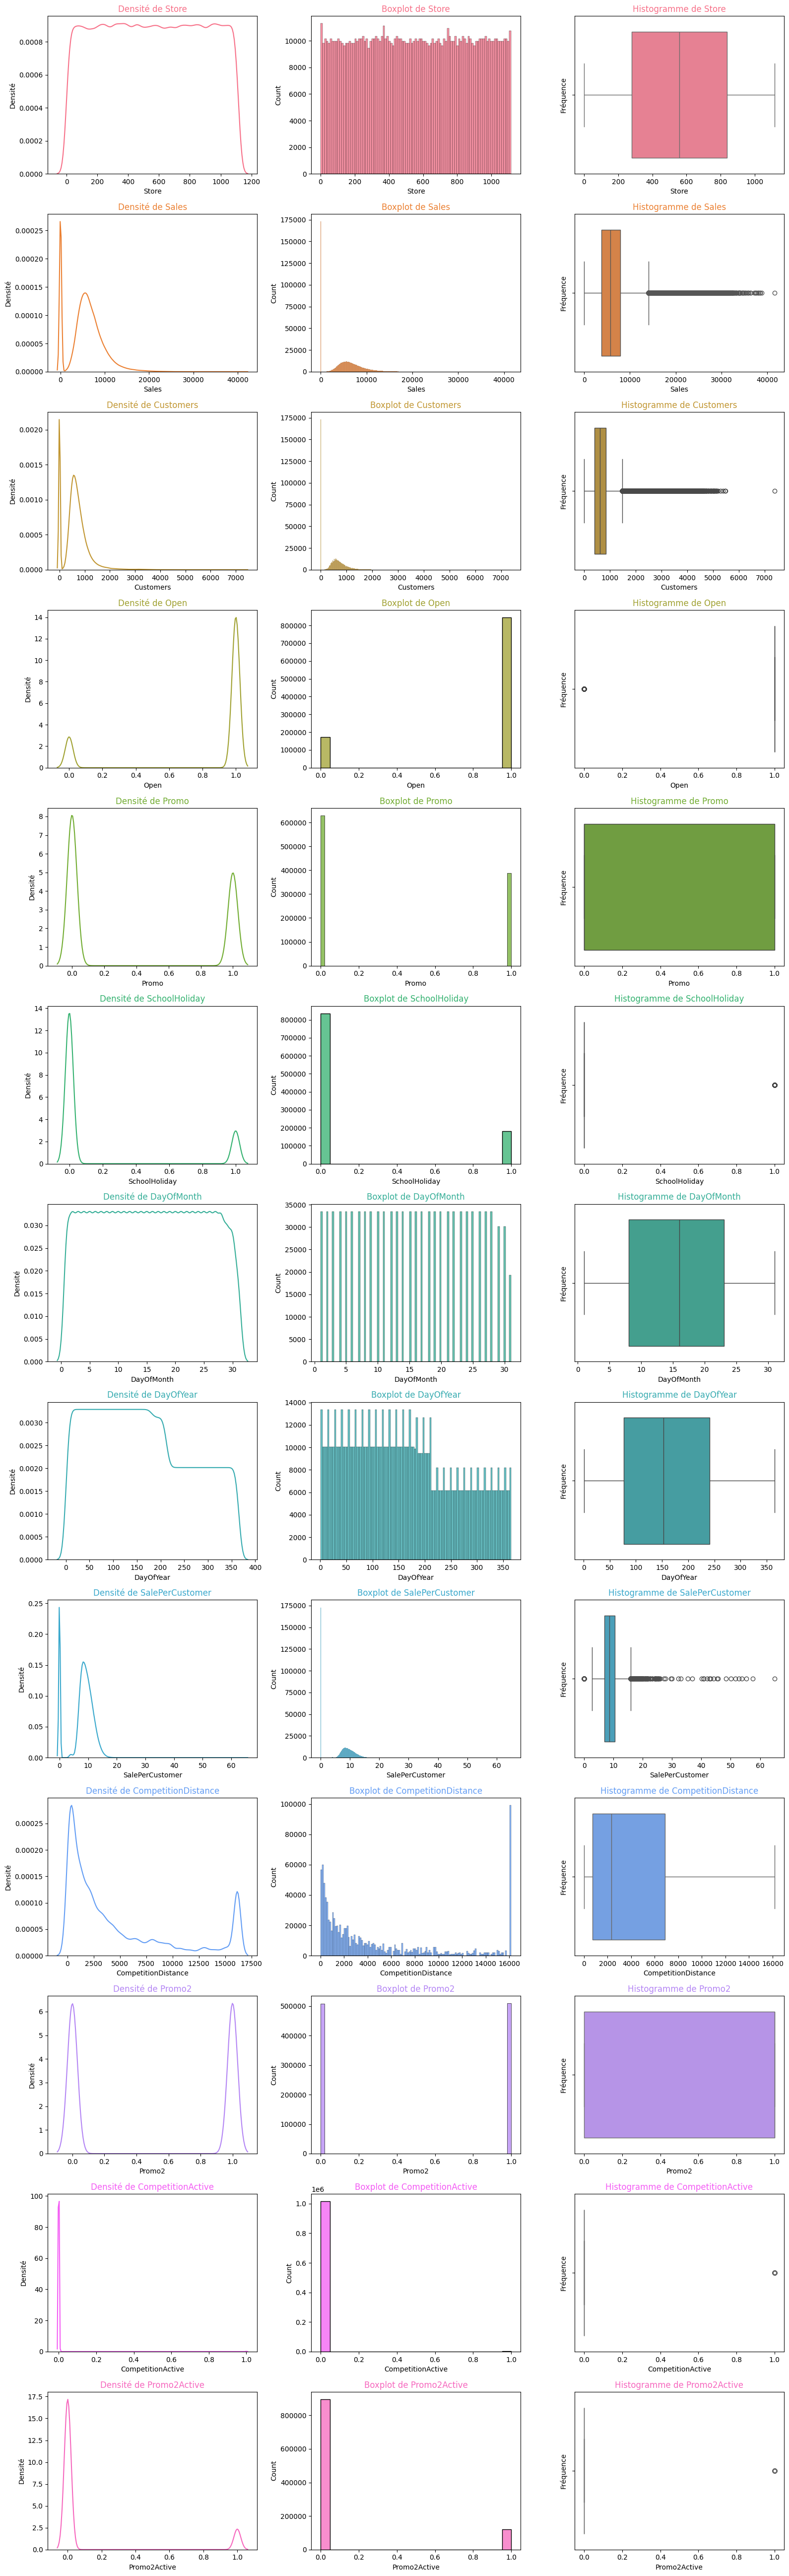

In [38]:
#Nombre de features pour organiser les sous-graphiques
df_quanti = df.select_dtypes(include=['number'])
df_quanti = df_quanti.drop(columns=['Year','Month','WeekOfYear','DayOfWeek'])
numerical_columns = df_quanti.columns
num_features = len(numerical_columns)

#Set de couleur pour chaque feature
colors = sns.color_palette('husl', num_features)

# Création d'une figure avec des sous-graphiques pour chaque feature
fig, axes = plt.subplots(num_features, 3, figsize=(16, 4 * num_features))

# Boucle sur chaque colonne pour tracer les courbes de densité et les boxplots
for i, (col, color) in enumerate(zip(df_quanti.columns, colors)):

     #Mesures mode et asymetrie:
     print(f"{col}")
     #print(f"Mode:",df_quanti[col].mode().values)
     print(f"Mesure d'asymetrie:",round(df_quanti[col].skew(),2))
     print()
    
     # KDE plot
     sns.kdeplot(df_quanti[col], ax=axes[i, 0], color=color)
     axes[i, 0].set_title(f'Densité de {col}', color=color)
     axes[i, 0].set_xlabel(col)
     axes[i, 0].set_ylabel('Densité')

     # Histogramme
     sns.histplot(df_quanti[col], kde=False, ax=axes[i, 1], color=color)
     axes[i, 2].set_title(f'Histogramme de {col}', color=color)
     axes[i, 2].set_xlabel(col)
     axes[i, 2].set_ylabel('Fréquence')
    
     # Box plot
     sns.boxplot(x=df_quanti[col], ax=axes[i, 2], color=color)
     axes[i, 1].set_title(f'Boxplot de {col}', color=color)
     axes[i, 1].set_xlabel(col)

 # Ajuster les espacements entre les sous-graphiques
plt.tight_layout()

 # Afficher les graphiques
plt.show()

## 4.2 Analyses multivariées

### 4.2.1 Focus sur sales au cours du temps

Ventes totales:

C:\Users\flore\AppData\Local\Temp\ipykernel_117748\1249995181.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df["Sales"].resample("M").sum()


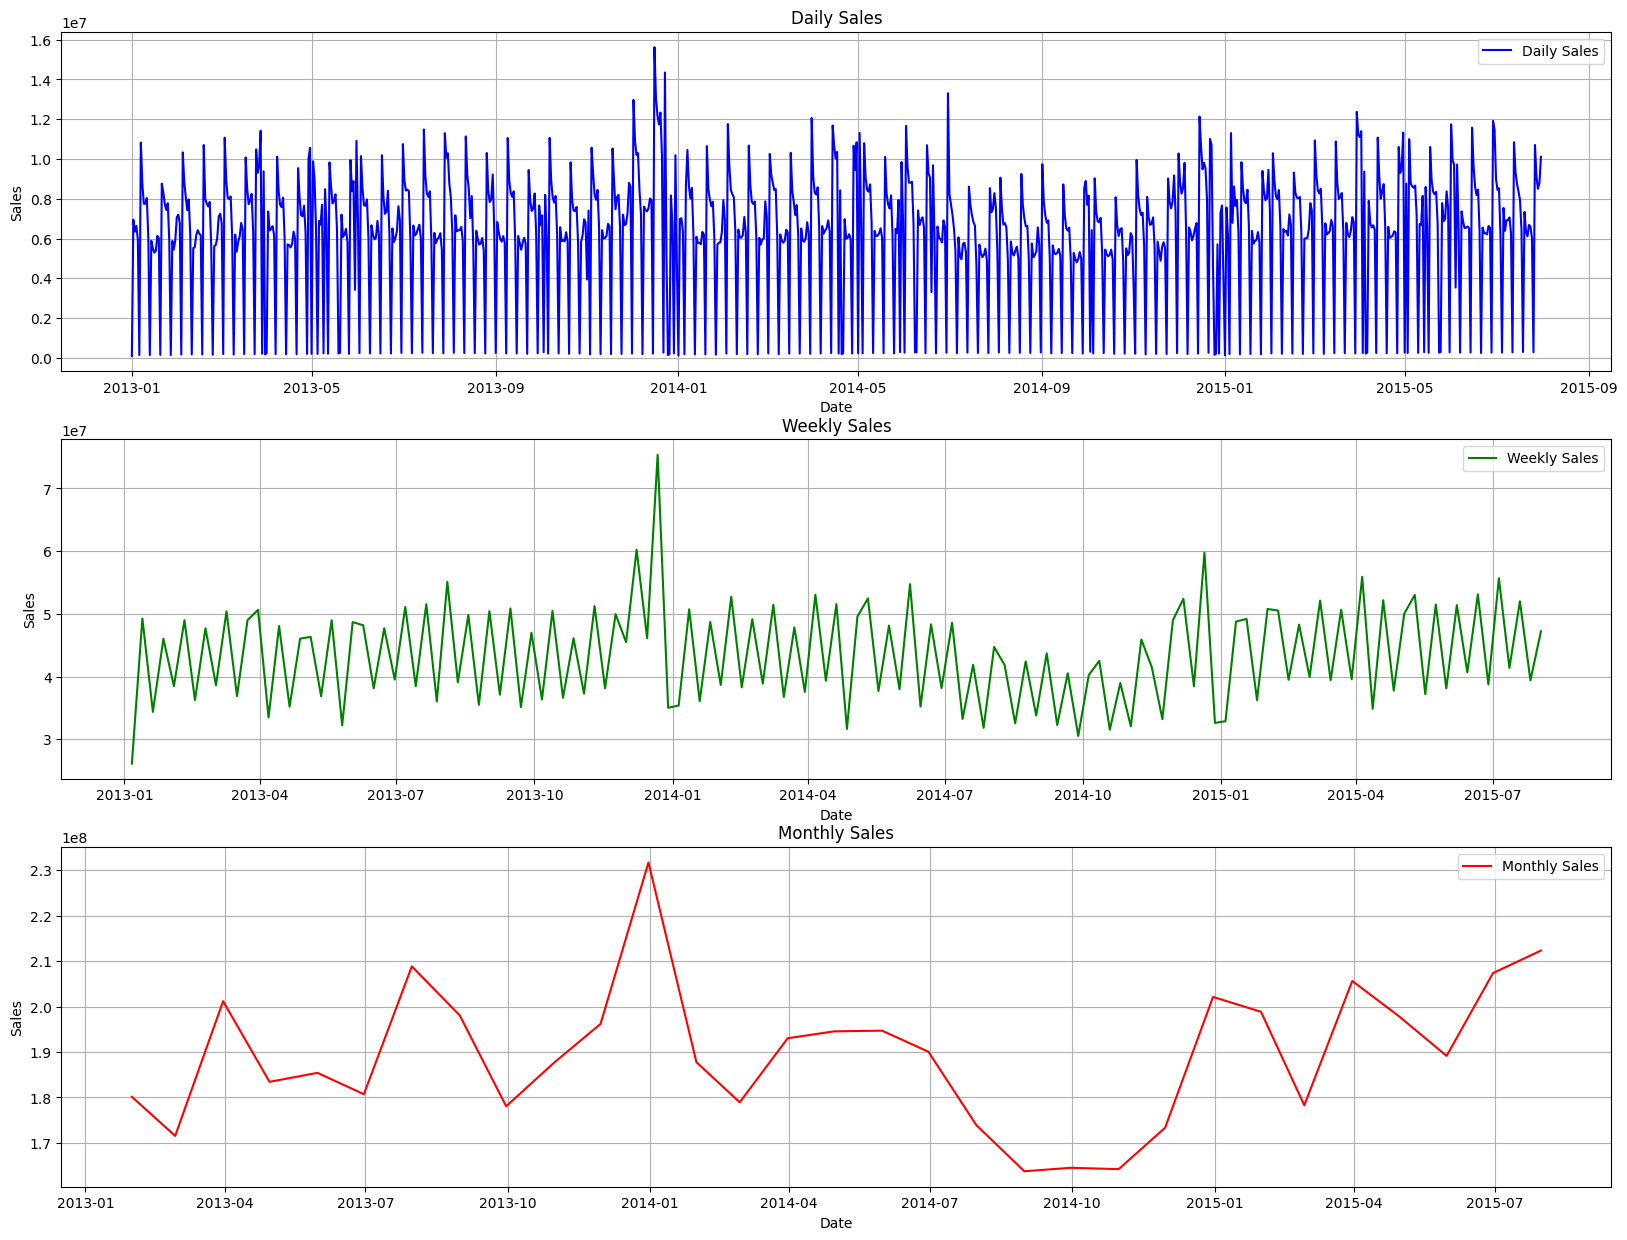

In [39]:
# Définir Date comme index
df.set_index("Date", inplace=True)

# Resampling pour Daily, Weekly et Monthly sales
daily_sales = df["Sales"].resample("D").sum()
weekly_sales = df["Sales"].resample("W").sum()
monthly_sales = df["Sales"].resample("M").sum()

# Afficher les graphiques
plt.figure(figsize=(20, 15))

# Daily Sales
plt.subplot(3, 1, 1)
plt.plot(daily_sales, label="Daily Sales", color="blue")
plt.title("Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid()

# Weekly Sales
plt.subplot(3, 1, 2)
plt.plot(weekly_sales, label="Weekly Sales", color="green")
plt.title("Weekly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid()

# Monthly Sales
plt.subplot(3, 1, 3)
plt.plot(monthly_sales, label="Monthly Sales", color="red")
plt.title("Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid()

#plt.tight_layout()
plt.show()


Ventes par année:

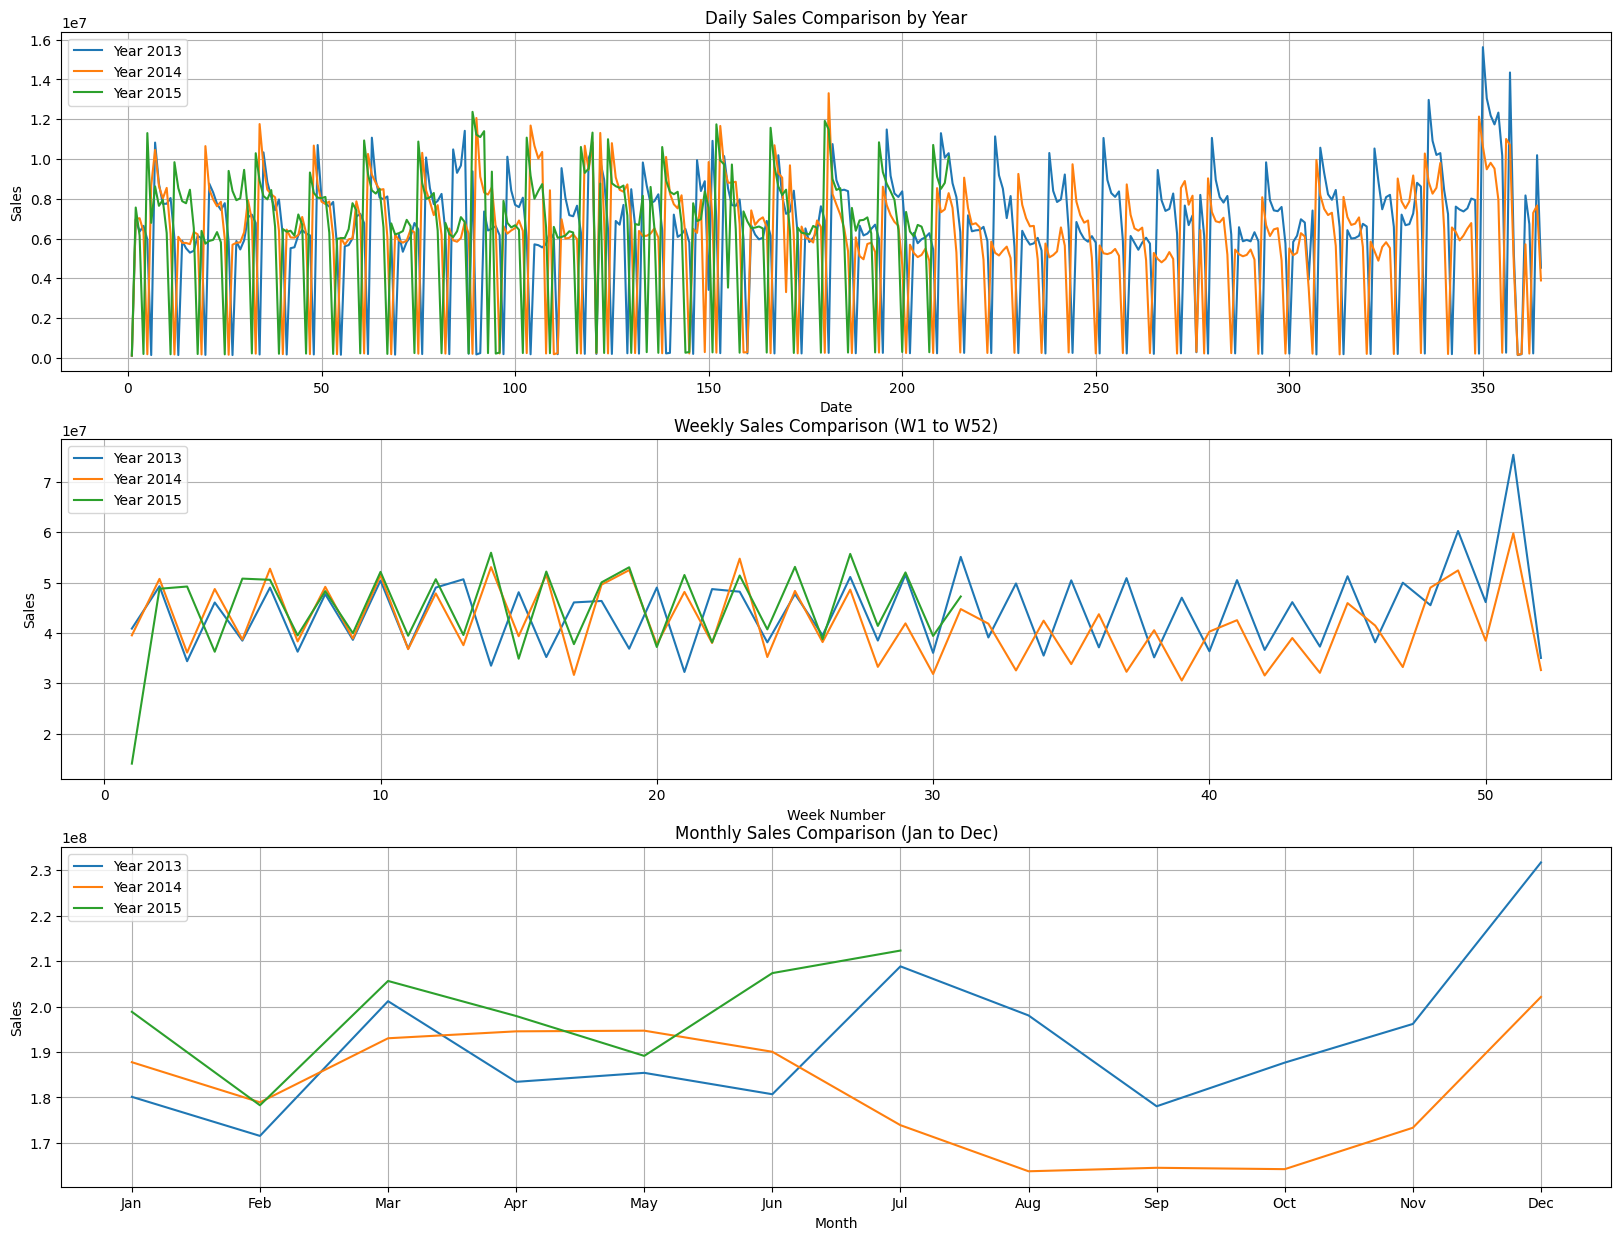

In [40]:
import matplotlib.pyplot as plt

# Extraire les ventes par année
years = df['Year'].unique()

# Créer la figure
plt.figure(figsize=(20, 15))

# Ventes quotidiennes (Daily Sales) - de 01/01 à 31/12 sans année
plt.subplot(3, 1, 1)

for year in years:
    daily_sales = df[df['Year'] == year].groupby('DayOfYear')['Sales'].sum()
    plt.plot(daily_sales, label=f"Year {year}")
plt.title("Daily Sales Comparison by Year")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid()

# Ventes hebdomadaires (Weekly Sales) - de W1 à W52 (ou 53)
plt.subplot(3, 1, 2)
for year in years:
    weekly_sales = df[df['Year'] == year].groupby('WeekOfYear')['Sales'].sum()
    plt.plot(weekly_sales, label=f"Year {year}")
plt.title("Weekly Sales Comparison (W1 to W52)")
plt.xlabel("Week Number")
plt.ylabel("Sales")
plt.legend()
plt.grid()

# Ventes mensuelles (Monthly Sales) - de Jan à Dec sans année
plt.subplot(3, 1, 3)
for year in years:
    monthly_sales = df[df['Year'] == year].groupby('Month')['Sales'].sum()
    # Enlever l'année de l'axe X
    monthly_sales.index = pd.to_datetime(monthly_sales.index, format='%m').strftime('%b')  # Formater pour afficher les mois (Jan, Feb, ...)
    plt.plot(monthly_sales, label=f"Year {year}")
plt.title("Monthly Sales Comparison (Jan to Dec)")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid()

plt.show()


### 4.2.2 Focus sur les magasins et assortiments

Ouverture/Fermeture des magasins hebdomadaires: sans surprise la plupart des magasins Rosswell de l'étude sont fermés les dimanches.
Les autres jours de la semaines, les fermetures visibles (outre ponctuelles=, seront surtout des vacances

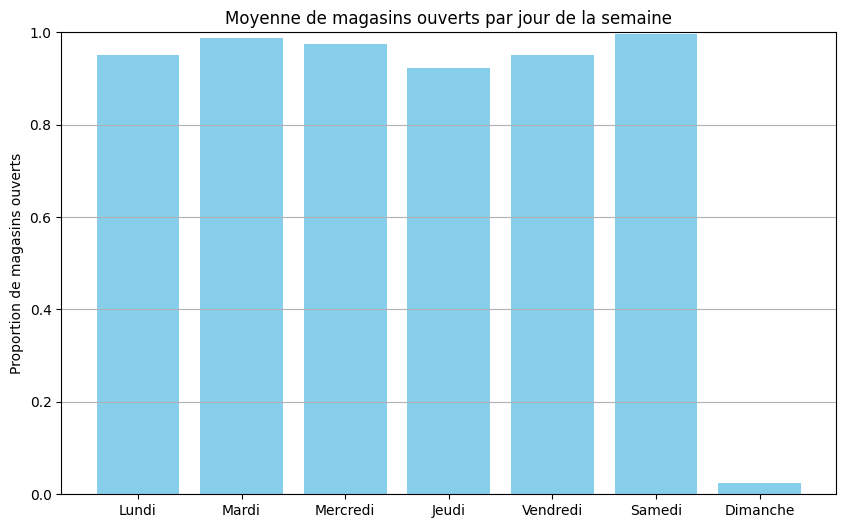

In [41]:
# Calculer la moyenne du nombre de magasins ouverts par jour de la semaine
mean_open_by_day = df.groupby("DayOfWeek")["Open"].mean()

# Mapper les jours pour les afficher:
day_labels = ["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"]

# Afficher le graphique
plt.figure(figsize=(10, 6))
plt.bar(day_labels, mean_open_by_day, color="skyblue")
plt.title("Moyenne de magasins ouverts par jour de la semaine")
plt.ylabel("Proportion de magasins ouverts")
plt.ylim(0, 1)
plt.grid(axis="y")

plt.show()

Ouverture des magasins au cours du temps:

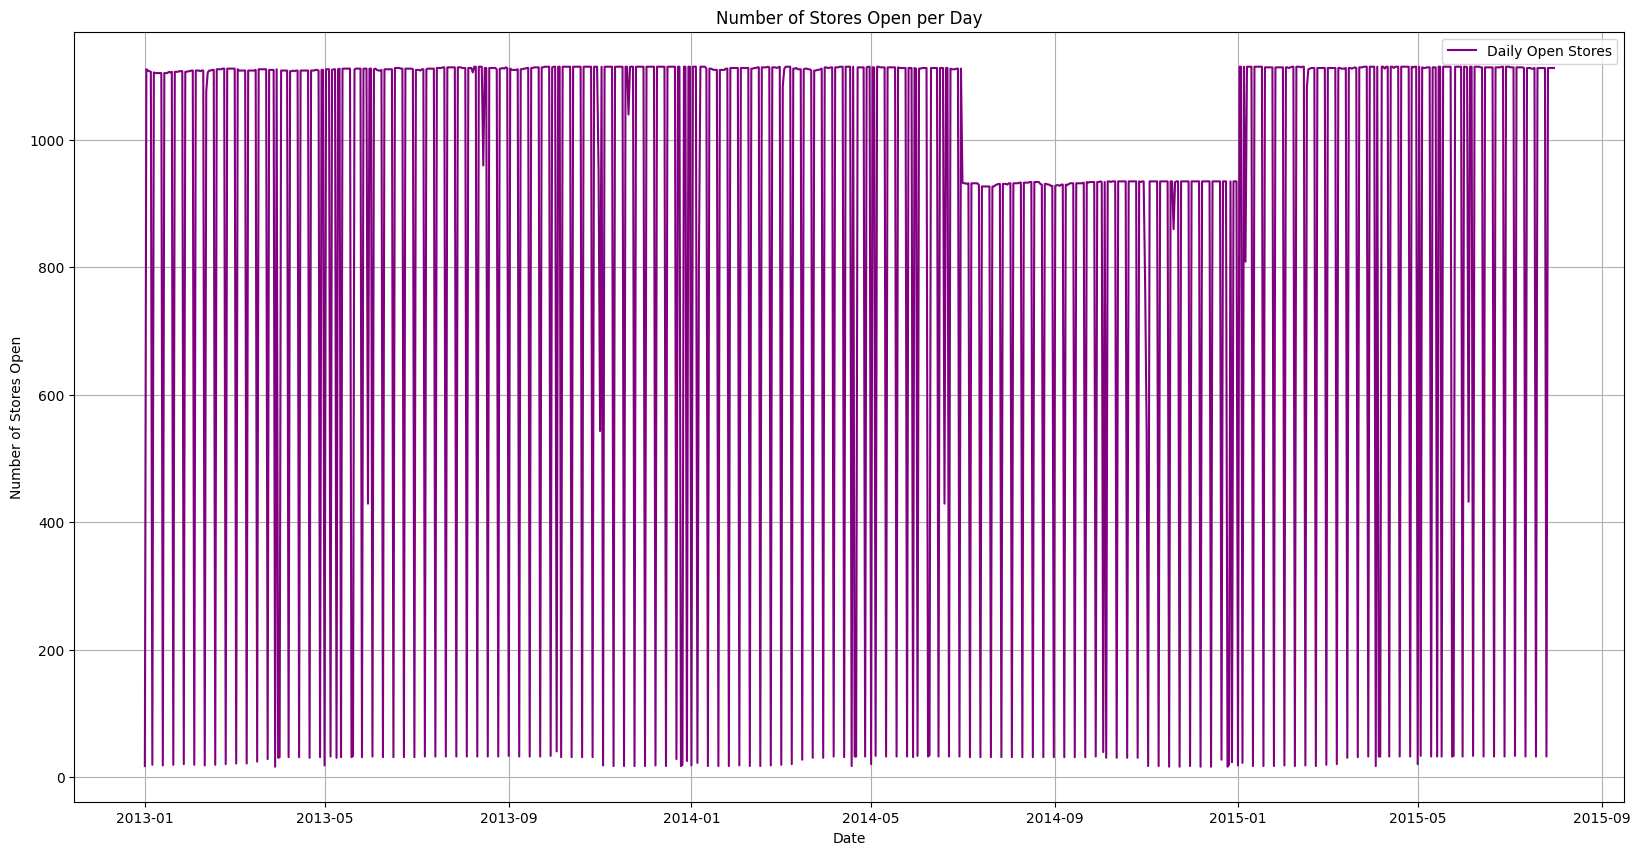

In [42]:
# Data extraction: daily count of open stores
daily_open_stores = df['Open'].resample('D').sum()  # Compte le nombre de magasins ouverts chaque jour

# Afficher le graphique
plt.figure(figsize=(20, 10))

# Plot Daily Open Stores
plt.plot(daily_open_stores, label="Daily Open Stores", color="purple")
plt.title("Number of Stores Open per Day")
plt.xlabel("Date")
plt.ylabel("Number of Stores Open")
plt.legend()
plt.grid()

plt.show()

On voit clairement un "drop" dans les ouvertures (outre les fermetures hebdo) de Juin 2014 à Janvier 2015.
Regardons si un type de magasin à fermé sur cette période:

<Figure size 2000x1000 with 0 Axes>

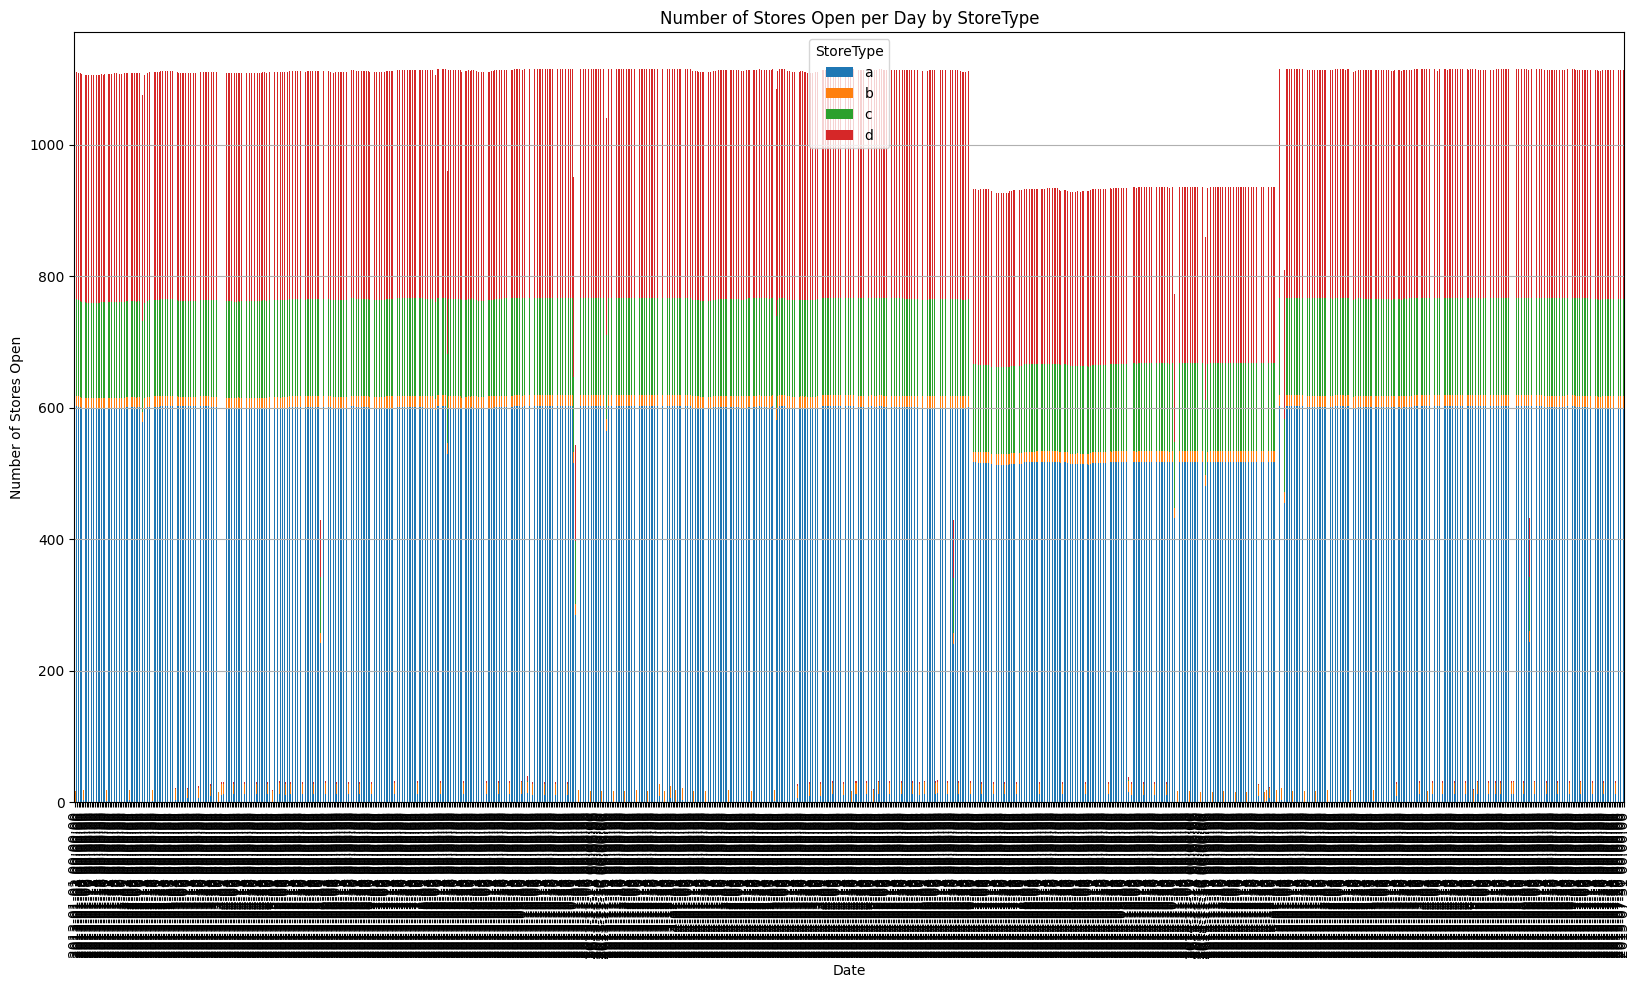

In [43]:
# Data extraction: daily count of open stores by store type
daily_open_stores_by_type = df.groupby([pd.Grouper(freq='D'), 'StoreType'])['Open'].sum().unstack(fill_value=0)

# Afficher le graphique
plt.figure(figsize=(20, 10))

# Plot Stacked Bar Chart for Daily Open Stores by StoreType
daily_open_stores_by_type.plot(kind='bar', stacked=True, figsize=(20, 10))

plt.title("Number of Stores Open per Day by StoreType")
plt.xlabel("Date")
plt.ylabel("Number of Stores Open")
plt.legend(title="StoreType")
plt.grid(True, axis='y')

plt.show()



Les ventes au cours du temps, par type de magasin:

C:\Users\flore\AppData\Local\Temp\ipykernel_117748\3027519327.py:36: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df[df["StoreType"] == store]["Sales"].resample("M").sum()


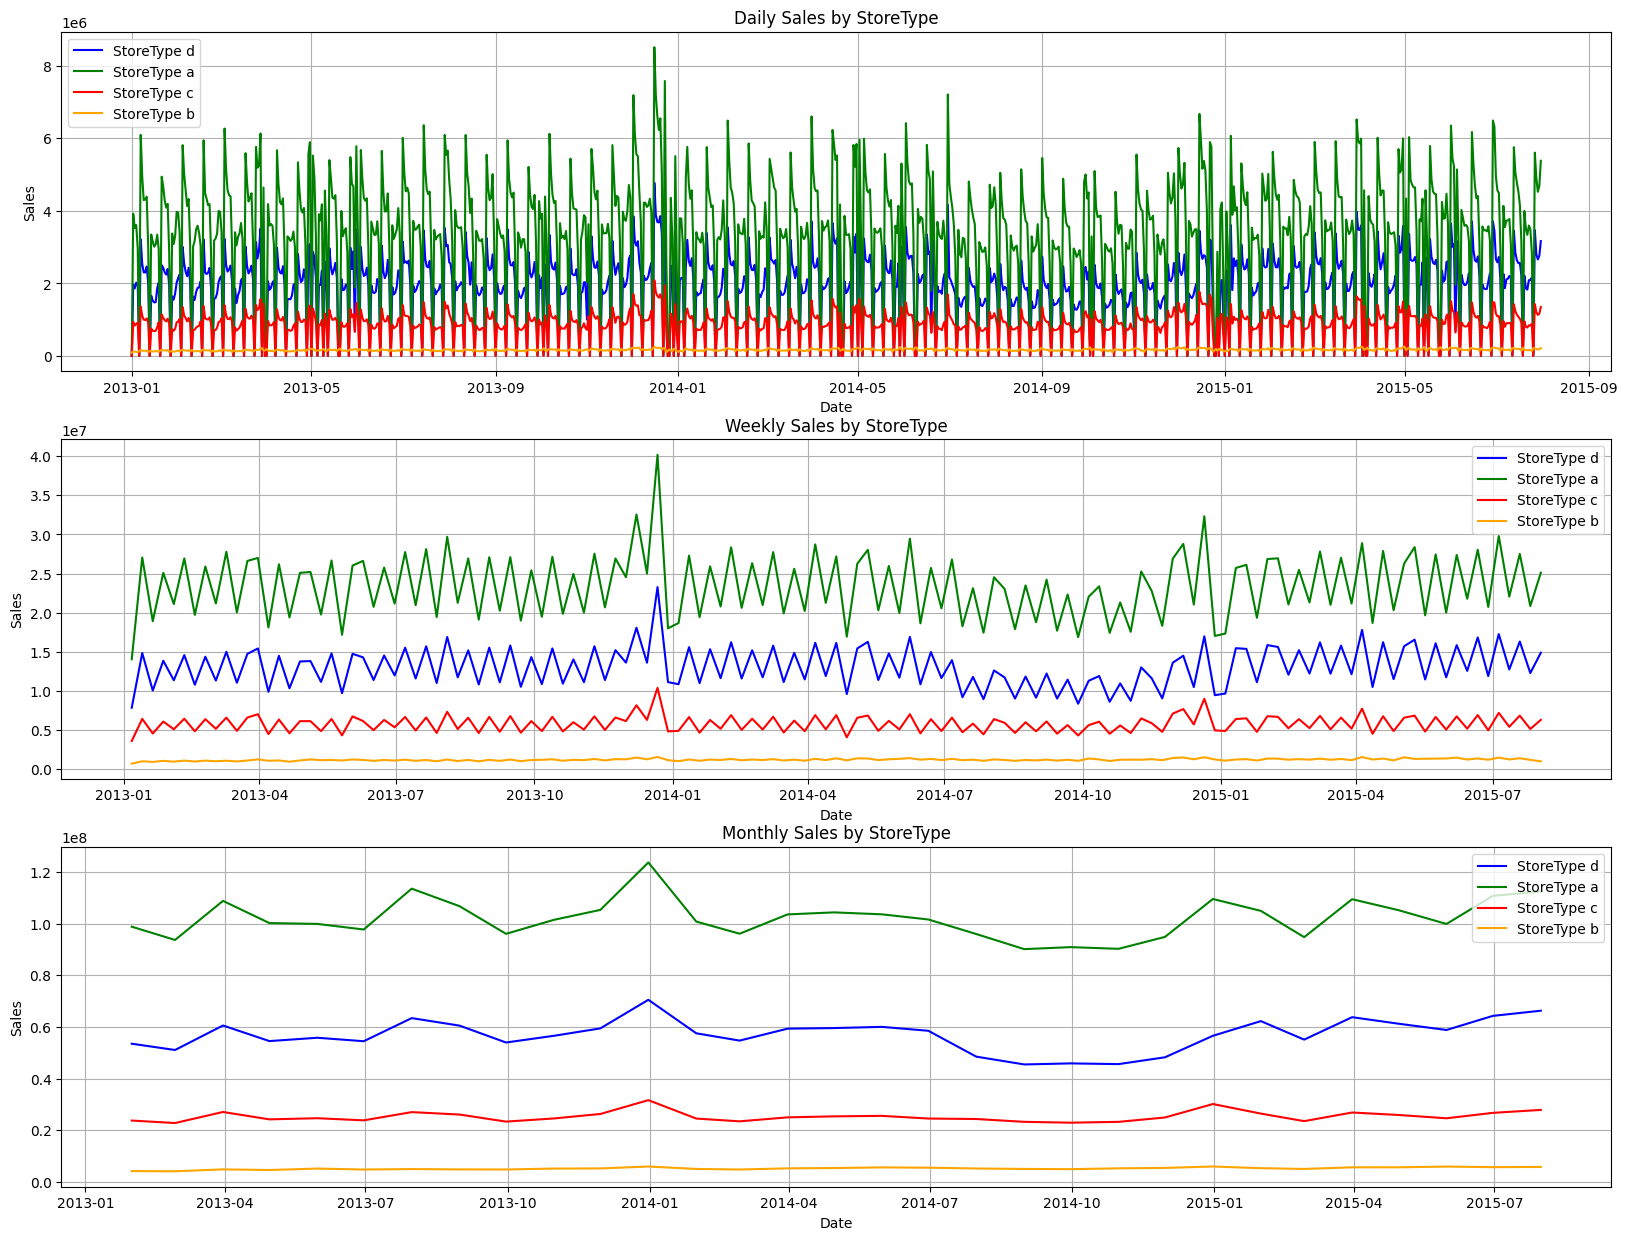

In [44]:
# Obtenir les types de magasins uniques
store_types = df["StoreType"].unique()

# Définir les couleurs pour chaque type de magasin
colors = ["blue", "green", "red", "orange"]
store_colors = dict(zip(store_types, colors))

# Créer la figure
plt.figure(figsize=(20, 15))

# Daily Sales
plt.subplot(3, 1, 1)
for store in store_types:
    daily_sales = df[df["StoreType"] == store]["Sales"].resample("D").sum()
    plt.plot(daily_sales, label=f"StoreType {store}", color=store_colors[store])
plt.title("Daily Sales by StoreType")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid()

# Weekly Sales
plt.subplot(3, 1, 2)
for store in store_types:
    weekly_sales = df[df["StoreType"] == store]["Sales"].resample("W").sum()
    plt.plot(weekly_sales, label=f"StoreType {store}", color=store_colors[store])
plt.title("Weekly Sales by StoreType")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid()

# Monthly Sales
plt.subplot(3, 1, 3)
for store in store_types:
    monthly_sales = df[df["StoreType"] == store]["Sales"].resample("M").sum()
    plt.plot(monthly_sales, label=f"StoreType {store}", color=store_colors[store])
plt.title("Monthly Sales by StoreType")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid()

plt.show()

les memes graphs, en focusant cette fois-ci sur les ventes par assortiment (a, b ou c)

C:\Users\flore\AppData\Local\Temp\ipykernel_117748\2669862157.py:40: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df[df["Assortment"] == assort]["Sales"].resample("M").sum()


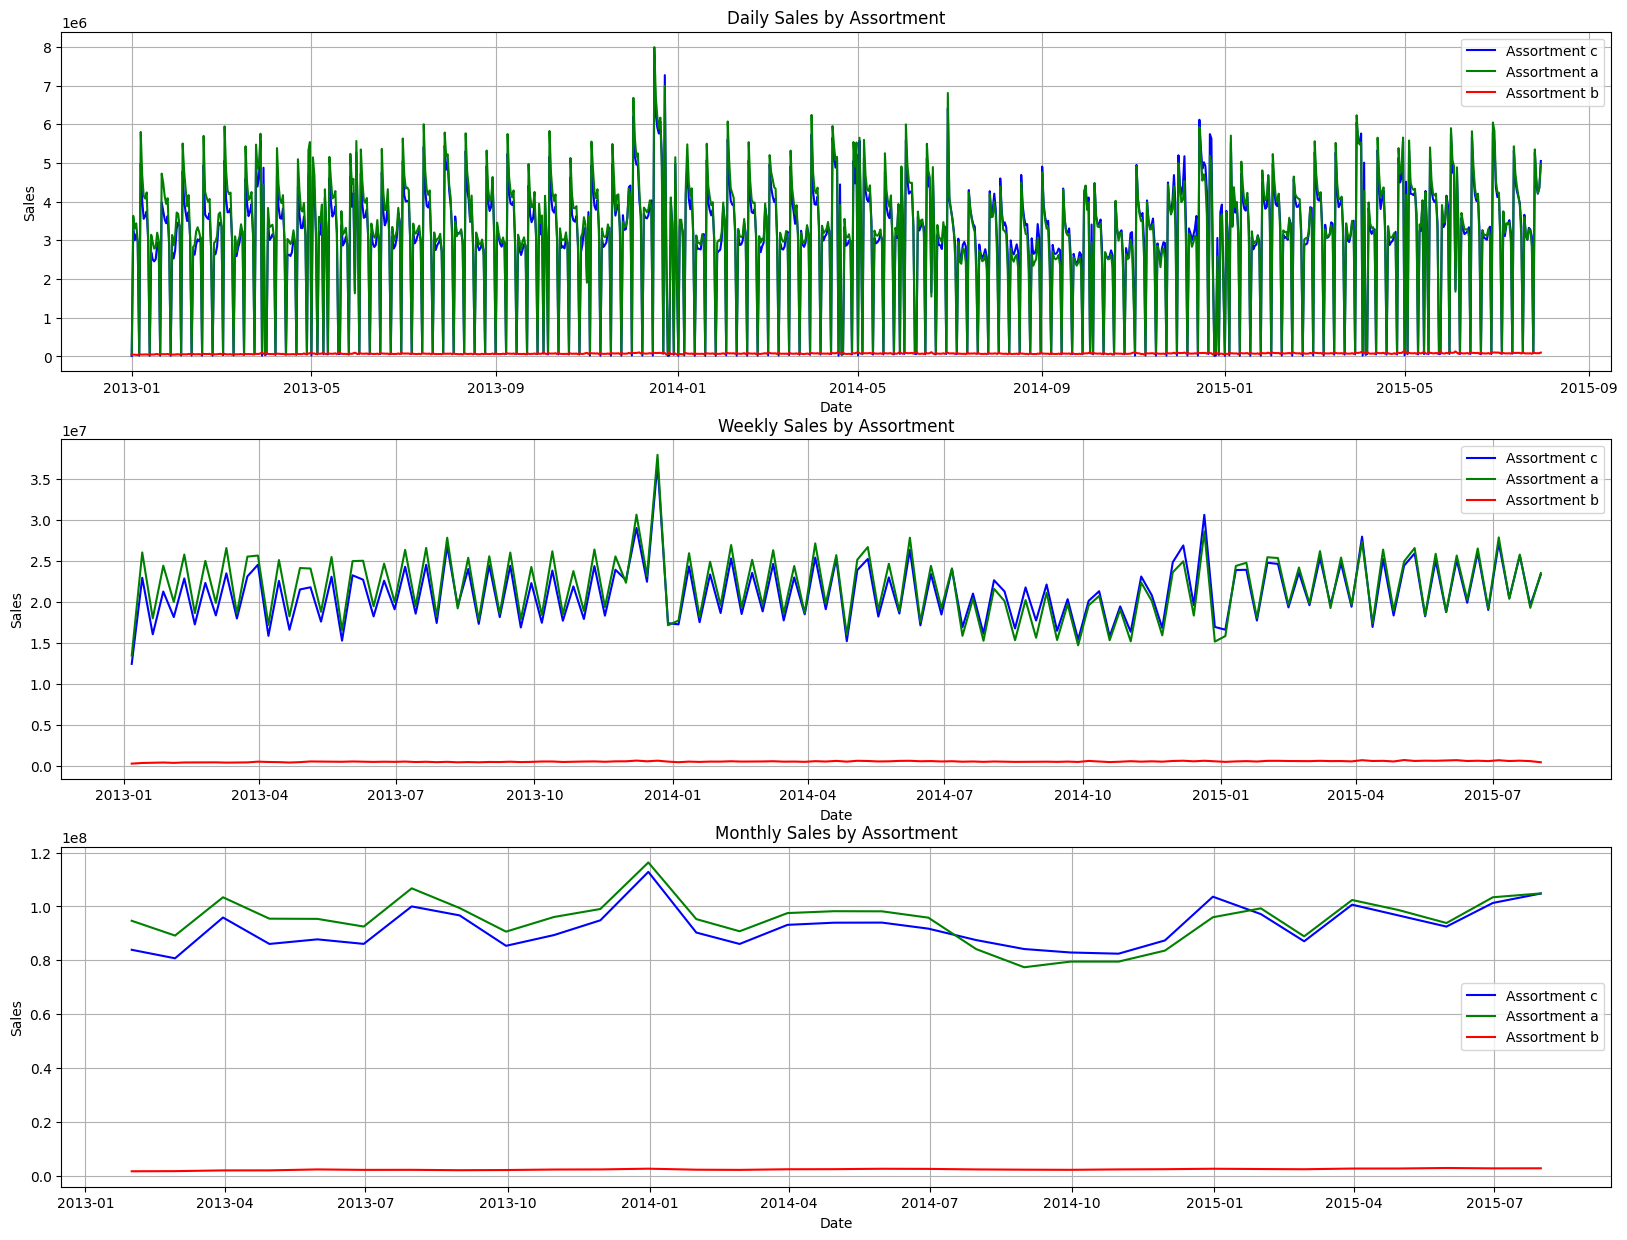

In [45]:
# df.reset_index(inplace=True)  # Réinitialiser l'index pour récupérer la colonne 'Date' perdue lors du merge
# df["Date"] = pd.to_datetime(df["Date"])  # Convertir 'Date' en datetime si nécessaire
# df.set_index("Date", inplace=True)  # Définir 'Date' comme index

# Obtenir les assortiments uniques
assortment = df["Assortment"].unique()

# Définir les couleurs pour chaque type d'assort
colors = ["blue", "green", "red"]
assort_colors = dict(zip(assortment, colors))

# Créer la figure
plt.figure(figsize=(20, 15))

# Daily Sales
plt.subplot(3, 1, 1)
for assort in assortment:
    daily_sales = df[df["Assortment"] == assort]["Sales"].resample("D").sum()
    plt.plot(daily_sales, label=f"Assortment {assort}", color=assort_colors[assort])
plt.title("Daily Sales by Assortment")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid()

# Weekly Sales
plt.subplot(3, 1, 2)
for assort in assortment:
    weekly_sales = df[df["Assortment"] == assort]["Sales"].resample("W").sum()
    plt.plot(weekly_sales, label=f"Assortment {assort}", color=assort_colors[assort])
plt.title("Weekly Sales by Assortment")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid()

# Monthly Sales
plt.subplot(3, 1, 3)
for assort in assortment:
    monthly_sales = df[df["Assortment"] == assort]["Sales"].resample("M").sum()
    plt.plot(monthly_sales, label=f"Assortment {assort}", color=assort_colors[assort])
plt.title("Monthly Sales by Assortment")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid()

plt.show()


In [46]:
df.groupby('StoreType')['Sales'].describe()

,count,mean,std,min,25%,50%,75%,max
StoreType,,,,,,,,
a,551627.0,5738.179710,3964.028134,0.0,3508.0,5618.0,7860.00,41551.0
b,15830.0,10058.837334,5280.525506,0.0,6227.0,9025.5,13082.75,38722.0
c,136840.0,5723.629246,3721.700886,0.0,3789.0,5766.0,7849.00,31448.0
d,312912.0,5641.819243,3473.393781,0.0,3986.0,5826.0,7691.00,38037.0


In [47]:
df.groupby("StoreType").agg({
    "Customers": "sum", 
    "Sales": "sum", 
    "SalePerCustomer": "mean"
})

,Customers,Sales,SalePerCustomer
StoreType,,,
a,363541434,3165334859,7.329461
b,31465621,159231395,5.045870
c,92129705,783221426,7.121365
d,156904995,1765392943,9.326423


In [48]:
df.groupby('Assortment')['Sales'].describe()

,count,mean,std,min,25%,50%,75%,max
Assortment,,,,,,,,
a,537445.0,5481.026096,3682.766186,0.0,3492.0,5463.0,7514.00,38722.0
b,8294.0,8553.931999,3882.418206,0.0,5523.0,8026.5,11233.25,22137.0
c,471470.0,6058.676567,3992.255662,0.0,4017.0,6039.0,8184.00,41551.0


In [49]:
df.groupby("Assortment").agg({
    "Customers": "sum", 
    "Sales": "sum", 
    "SalePerCustomer": "mean"
})

,Customers,Sales,SalePerCustomer
Assortment,,,
a,332766938,2945750070,7.558109
b,16972525,70946312,4.121054
c,294302292,2856484241,8.313561


In [50]:
df.groupby(['StoreType','Assortment'])['Sales'].describe()

count          mean          std     min      25%  \
StoreType Assortment                                                         
a         a           346389.0   5398.858310  3722.911193     0.0   3301.0   
          c           205238.0   6310.867032  4280.123003     0.0   3974.0   
b         a             6594.0  10821.619806  5864.048965     0.0   6804.5   
          b             8294.0   8553.931999  3882.418206     0.0   5523.0   
          c              942.0  17969.556263  2931.927599  8498.0  16078.5   
c         a            70878.0   5647.174314  3483.833839     0.0   3915.0   
          c            65962.0   5805.782193  3959.789883     0.0   3657.0   
d         a           113584.0   5317.885943  3258.385659     0.0   3709.0   
          c           199328.0   5826.407660  3577.069398     0.0   4181.0   

                          50%       75%      max  
StoreType Assortment                              
a         a            5312.0   7426.00  38025.0  
          c            6176.0   8561.00  41551.0  
b         a            9389.0  13814.75  38722.0  
          b            8026.5  11233.25  22137.0  
          c           18029.5  19867.75  28680.0  
c         a            5841.0   7797.75  28242.0  
          c            5688.0   7914.00  31448.0  
d         a            5507.0   7330.00  33071.0  
          c            6008.0   7890.00  38037.0

In [51]:
df.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,DayOfMonth,DayOfYear,WeekOfYear,SalePerCustomer,StoreType,Assortment,CompetitionDistance,Promo2,PromoInterval,CompetitionActive,Promo2Active
Date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,1115,2,0,0,0,0,a,1,2013,1,1,1,1,0.0,d,c,5350.0,1,"Mar,Jun,Sept,Dec",0,0
2013-01-01,379,2,0,0,0,0,a,1,2013,1,1,1,1,0.0,d,a,6630.0,0,No_Promo2,0,0
2013-01-01,378,2,0,0,0,0,a,1,2013,1,1,1,1,0.0,a,c,2140.0,0,No_Promo2,0,0
2013-01-01,377,2,0,0,0,0,a,1,2013,1,1,1,1,0.0,a,c,100.0,1,"Feb,May,Aug,Nov",0,0
2013-01-01,376,2,0,0,0,0,a,1,2013,1,1,1,1,0.0,a,a,160.0,0,No_Promo2,0,0


### 4.2.3 Focus sur les promos

Impact promo sur le panier moyen du conso:

In [52]:
# Calcul du panier moyen par client pour chaque condition de promo

# Sans aucune promo
no_promo = df[df["Promo"] == 0]
basket_per_customer_no_promo = no_promo["Sales"].sum() / no_promo["Customers"].sum()

# Si promo 1
promo_1 = df[df["Promo"] == 1]
basket_per_customer_promo_1 = promo_1["Sales"].sum() / promo_1["Customers"].sum()

# Si promo 2
promo_2 = df[df["Promo2"] == 1]
basket_per_customer_promo_2 = promo_2["Sales"].sum() / promo_2["Customers"].sum()

# Si promo 1 ET promo 2
promo_1_and_2 = df[(df["Promo"] == 1) & (df["Promo2"] == 1)]
basket_per_customer_promo_1_and_2 = promo_1_and_2["Sales"].sum() / promo_1_and_2["Customers"].sum()

# Affichage des résultats
print(f"Panier moyen sans aucune promo : {basket_per_customer_no_promo:.2f}")
print(f"Panier moyen avec promo 1 : {basket_per_customer_promo_1:.2f}")
print(f"Panier moyen avec promo 2 : {basket_per_customer_promo_2:.2f}")
print(f"Panier moyen avec promo 1 et promo 2 : {basket_per_customer_promo_1_and_2:.2f}")

Panier moyen sans aucune promo : 8.51
Panier moyen avec promo 1 : 9.74
Panier moyen avec promo 2 : 9.63
Panier moyen avec promo 1 et promo 2 : 10.31


Impact promo sur le nb de clients moyen par magasin ouvert

In [53]:
# Sans aucune promo
no_promo = df[df["Promo"] == 0]
# Filtrer uniquement les magasins ouverts
no_promo_open = no_promo[no_promo["Open"] == 1]
# Calculer le nombre total de clients par magasin ouvert par jour
clients_per_store_no_promo = no_promo_open.groupby([no_promo_open.index.date, 'Store'])['Customers'].sum()
# Calculer la moyenne des clients par magasin ouvert
clients_per_store_no_promo_avg = clients_per_store_no_promo.mean()

# Si promo 1
promo_1 = df[df["Promo"] == 1]
# Filtrer uniquement les magasins ouverts
promo_1_open = promo_1[promo_1["Open"] == 1]
# Calculer le nombre total de clients par magasin ouvert par jour
clients_per_store_promo_1 = promo_1_open.groupby([promo_1_open.index.date, 'Store'])['Customers'].sum()
# Calculer la moyenne des clients par magasin ouvert
clients_per_store_promo_1_avg = clients_per_store_promo_1.mean()

# Si promo 2
promo_2 = df[df["Promo2"] == 1]
# Filtrer uniquement les magasins ouverts
promo_2_open = promo_2[promo_2["Open"] == 1]
# Calculer le nombre total de clients par magasin ouvert par jour
clients_per_store_promo_2 = promo_2_open.groupby([promo_2_open.index.date, 'Store'])['Customers'].sum()
# Calculer la moyenne des clients par magasin ouvert
clients_per_store_promo_2_avg = clients_per_store_promo_2.mean()

# Si promo 1 ET promo 2
promo_1_and_2 = df[(df["Promo"] == 1) & (df["Promo2"] == 1)]
# Filtrer uniquement les magasins ouverts
promo_1_and_2_open = promo_1_and_2[promo_1_and_2["Open"] == 1]
# Calculer le nombre total de clients par magasin ouvert par jour
clients_per_store_promo_1_and_2 = promo_1_and_2_open.groupby([promo_1_and_2_open.index.date, 'Store'])['Customers'].sum()
# Calculer la moyenne des clients par magasin ouvert
clients_per_store_promo_1_and_2_avg = clients_per_store_promo_1_and_2.mean()

# Affichage des résultats
print(f"Nb clients moyen par magasin ouvert sans aucune promo : {clients_per_store_no_promo_avg:.0f}")
print(f"Nb clients moyen par magasin ouvert avec promo 1 : {clients_per_store_promo_1_avg:.0f}")
print(f"Nb clients moyen par magasin ouvert avec promo 2 : {clients_per_store_promo_2_avg:.0f}")
print(f"Nb clients moyen par magasin ouvert avec promo 1 et promo 2 : {clients_per_store_promo_1_and_2_avg:.0f}")


Nb clients moyen par magasin ouvert sans aucune promo : 697
Nb clients moyen par magasin ouvert avec promo 1 : 844
Nb clients moyen par magasin ouvert avec promo 2 : 681
Nb clients moyen par magasin ouvert avec promo 1 et promo 2 : 760


On voit donc que:
la promo classique impacte à la hausse à la fois le montant du panier moyen et le nombre de clients se rendant en magasin
la promo 2 impacte à la hausse le panier moyen mais n'attire pas plus de monde qu'un jour sans promo
promo 1 & 2 ont un fort impact sur le panier moyen et attire également plus de monde.

Regardons maintenant Promo 2 et définissons d'abord une nouvelle feature qui flag si une promo 2 est active ou non:
Probleme: on ne sais pas combien de temps dure la promo 2; on supposera qu'elle dure un mois.

In [54]:
print(df["PromoInterval"].unique())

['Mar,Jun,Sept,Dec' 'No_Promo2' 'Feb,May,Aug,Nov' 'Jan,Apr,Jul,Oct']


Promo2Active
0    7032.806453
1    6497.519319
Name: Sales, dtype: float64
Promo2Active
0    722467
1    121925
Name: count, dtype: int64


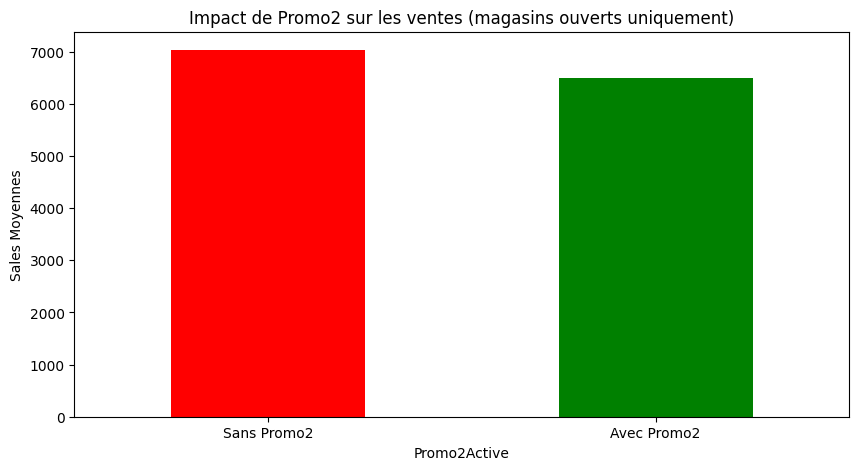

In [55]:
# Filtrer uniquement les magasins ouverts
df_open = df[df["Open"] == 1]

# Calcul de la moyenne des ventes selon Promo2Active
sales_mean_promo2 = df_open.groupby("Promo2Active")["Sales"].mean()
count_promo2 = df_open["Promo2Active"].value_counts()

print(sales_mean_promo2)
print(count_promo2)

# Affichage des résultats
plt.figure(figsize=(10, 5))
sales_mean_promo2.plot(kind="bar", color=["red", "green"])
plt.xticks(ticks=[0, 1], labels=["Sans Promo2", "Avec Promo2"], rotation=0)
plt.ylabel("Sales Moyennes")
plt.title("Impact de Promo2 sur les ventes (magasins ouverts uniquement)")
plt.show()

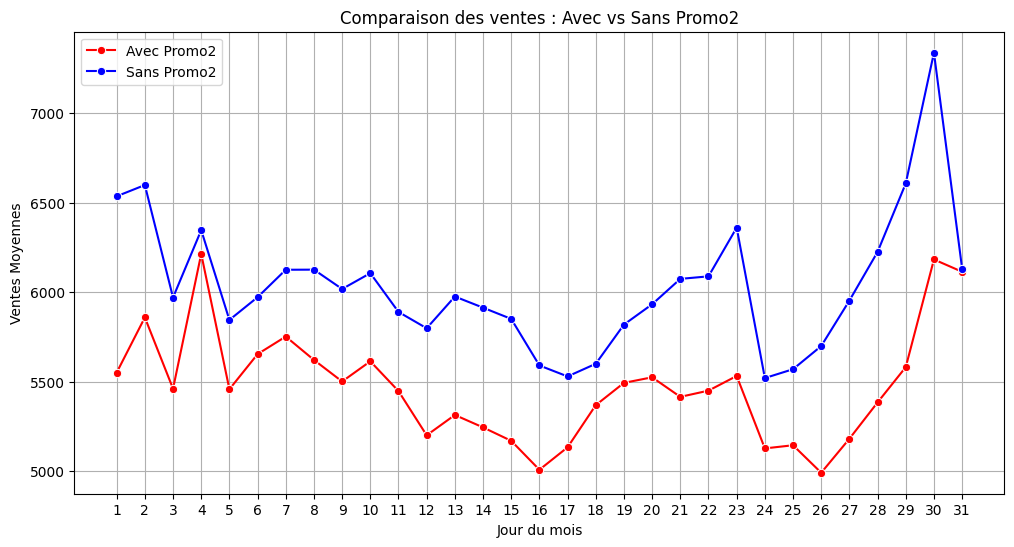

In [56]:
# Filtrage des données:
# Promo 2 active ou non (pour comparaison)
# + store Open only. on ne veut pas prendre en compte les magasins fermés
# + Promo = 0 On ne veut pas prendre en compte les occurences où il y a eu une Promo classique qui peut brouiller l'analyse)

df_promo_active = df[(df["Promo2Active"] == 1) & (df["Open"] == 1) & (df["Promo"] == 0)].copy()
df_no_promo = df[(df["Promo2Active"] == 0) & (df["Open"] == 1)& (df["Promo"] == 0)].copy()

# Extraire le jour du mois
df_promo_active["DayOfMonth"] = df_promo_active.index.day
df_no_promo["DayOfMonth"] = df_no_promo.index.day

# Moyenne des ventes par jour du mois
daily_sales_promo = df_promo_active.groupby("DayOfMonth")["Sales"].mean()
daily_sales_no_promo = df_no_promo.groupby("DayOfMonth")["Sales"].mean()

# Tracer les courbes
plt.figure(figsize=(12, 6))
sns.lineplot(x=daily_sales_promo.index, y=daily_sales_promo.values, marker="o", label="Avec Promo2", color="red")
sns.lineplot(x=daily_sales_no_promo.index, y=daily_sales_no_promo.values, marker="o", label="Sans Promo2", color="blue")

# Personnalisation du graphique
plt.xlabel("Jour du mois")
plt.ylabel("Ventes Moyennes")
plt.title("Comparaison des ventes : Avec vs Sans Promo2")
plt.xticks(range(1, 32))
plt.legend()
plt.grid(True)

# Afficher le graphique
plt.show()


Etonnamment, la promo 2 ne semble pas avoir d'impact positif dans les 30premiers jours, vs des ventes classiques sans promo 2;

### 4.2.3 Corrélation entre les features:

Pour rappel, du calcul précédent de corrélation entre les features et la cible (les ventes journalières)

In [57]:
#Affichage
print('Affichage du coefficient de corrélation de Pearson de chaque feature vs TARGET:')
correlations

Affichage du coefficient de corrélation de Pearson de chaque feature vs TARGET:


Sales                        100.00
Customers                     89.47
Open                          67.85
SalePerCustomer               65.88
DayOfWeek                     46.21
Promo                         45.23
Promo2                         9.10
SchoolHoliday                  8.51
Promo2SinceWeek                5.96
WeekOfYear                     5.29
Month                          4.88
DayOfYear                      4.75
CompetitionOpenSinceMonth      2.83
CompetitionDistance            2.57
Year                           2.35
Promo2SinceYear                2.11
CompetitionOpenSinceYear       1.27
DayOfMonth                     1.16
Store                          0.51
Name: Sales, dtype: float64

Calculons maintenant la variable de corrélation entre toutes les variables:

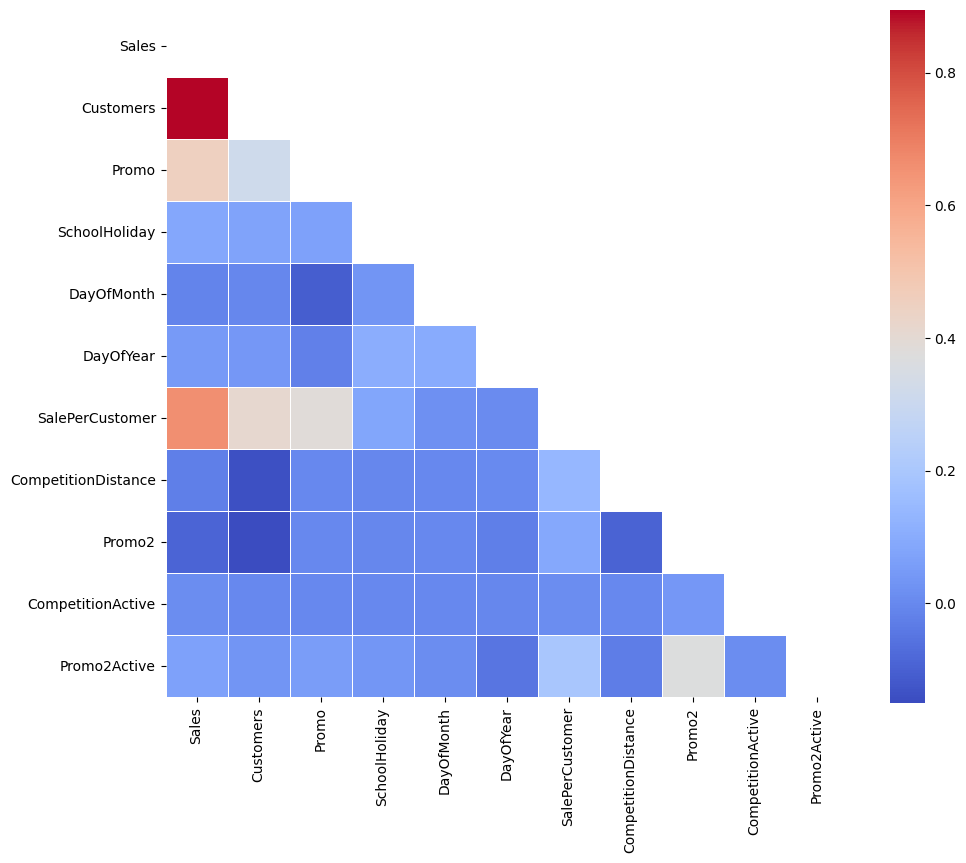

In [58]:
# Compute the correlation matrix 
# exclude 'Open' variable
corr_all = df_quanti.drop(['Store','Open'], axis = 1).corr()

# Generate a mask for the upper triangle
mask = np.zeros_like(corr_all, dtype = np.bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize = (11, 9))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr_all, mask = mask,
            square = True, linewidths = .5, ax = ax, cmap = "coolwarm")      
plt.show()

# 5. Features engineering

### 5.1.3 Encodage via One hot encoder

Technique avec One hot encoder, via la fonction get_dummies de panda:

In [59]:
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
print(categorical_cols)

['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval']


In [60]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Convertir les booléens en int
df_encoded = df_encoded.astype({col: int for col in df_encoded.select_dtypes(include='bool').columns})
print('Training Features shape: ', df_encoded.shape)

Training Features shape:  (1017209, 28)


In [61]:
df_encoded.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,Year,Month,DayOfMonth,DayOfYear,WeekOfYear,SalePerCustomer,CompetitionDistance,Promo2,CompetitionActive,Promo2Active,StateHoliday_a,StateHoliday_b,StateHoliday_c,StoreType_b,StoreType_c,StoreType_d,Assortment_b,Assortment_c,"PromoInterval_Jan,Apr,Jul,Oct","PromoInterval_Mar,Jun,Sept,Dec",PromoInterval_No_Promo2
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2013-01-01,1115,2,0,0,0,0,1,2013,1,1,1,1,0.0,5350.0,1,0,0,1,0,0,0,0,1,0,1,0,1,0
2013-01-01,379,2,0,0,0,0,1,2013,1,1,1,1,0.0,6630.0,0,0,0,1,0,0,0,0,1,0,0,0,0,1
2013-01-01,378,2,0,0,0,0,1,2013,1,1,1,1,0.0,2140.0,0,0,0,1,0,0,0,0,0,0,1,0,0,1
2013-01-01,377,2,0,0,0,0,1,2013,1,1,1,1,0.0,100.0,1,0,0,1,0,0,0,0,0,0,1,0,0,0
2013-01-01,376,2,0,0,0,0,1,2013,1,1,1,1,0.0,160.0,0,0,0,1,0,0,0,0,0,0,0,0,0,1


Remplacer les NaN par la valeur max (avant normalisation)

In [62]:
df_encoded['CompetitionDistance'] = df_encoded['CompetitionDistance'].fillna(df_encoded['CompetitionDistance'].max())

In [63]:
def normalize_per_series(df, cols_to_normalize):
    """
    Normalise les colonnes numériques spécifiées par série (magasin ici).
    
    Args:
        df (pd.DataFrame): DataFrame avec les données d'entrée.
        cols_to_normalize (list): Liste des colonnes à normaliser (numériques continues).
    
    Returns:
        df_normalized (pd.DataFrame): DataFrame avec les colonnes normalisées par série.
    """
    df_normalized = df.copy()
    
    # Appliquer la normalisation sur les séries temporelles par magasin
    for col in cols_to_normalize:
        scaler = StandardScaler()
        # Appliquer la normalisation sur chaque groupe (magasin)
        df_normalized[col] = df_normalized.groupby('Store')[col].transform(lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten())
    
    return df_normalized

In [64]:
def create_cyclic_features(df, cols=['DayOfWeek', 'Month']):
    """
    Crée des features cycliques pour les colonnes spécifiées (sin/cos).
    
    Args:
        df (pd.DataFrame): DataFrame avec les colonnes d'origine.
        cols (list): Liste des colonnes à transformer en features cycliques.
    
    Returns:
        df (pd.DataFrame): DataFrame avec les features cycliques ajoutées.
    """
    for col in cols:
        # Transformation en sin/cos pour la cyclicité
        df[f'{col}_sin'] = np.sin(2 * np.pi * df[col] / df[col].max())
        df[f'{col}_cos'] = np.cos(2 * np.pi * df[col] / df[col].max())
    return df

In [65]:
def get_filtered_features(df, target_col='Sales'):
    """
    Filtre automatiquement les colonnes pour l'entrainement de modèles comme ETSformer, Tide et NeuralProphet.
    Ajoute des features cycliques pour DayOfWeek et Month.
    
    Args:
        df (pd.DataFrame): DataFrame d'entrée.
        target_col (str): Nom de la colonne cible (ex: 'Sales').
    
    Returns:
        features (list): Liste des colonnes filtrées à utiliser pour l'entraînement.
        df_filtered (pd.DataFrame): DataFrame avec les features filtrées et cycliques.
    """
    # Liste des colonnes à exclure
    # cols_to_exclude = [target_col, 'SalePerCustomer', 'Customers', 'Year', 'DayOfMonth', 'DayOfYear', 'WeekOfYear']
    cols_to_exclude = ['SalePerCustomer', 'Customers', 'Year', 'DayOfMonth', 'DayOfYear', 'WeekOfYear']
    
    # Colonnes catégorielles et binaires
    categorical_cols = ['StateHoliday_a', 'StateHoliday_b', 'StateHoliday_c',
                        'StoreType_b', 'StoreType_c', 'StoreType_d',
                        'Assortment_b', 'Assortment_c', 'PromoInterval_Jan,Apr,Jul,Oct',
                        'PromoInterval_Mar,Jun,Sept,Dec', 'PromoInterval_No_Promo2']
    
    # Colonnes temporelles ou explicatives à garder
    time_related_cols = ['DayOfWeek', 'Month', 'Open', 'Promo', 'Promo2', 'Promo2Active', 'SchoolHoliday', 
                         'CompetitionDistance', 'CompetitionActive']
    
    # Combiner toutes les colonnes à garder
    keep_cols = ['Store'] + [target_col] + time_related_cols + categorical_cols
    
    # Créer les features cycliques
    df_filtered = create_cyclic_features(df[keep_cols].copy(), cols=['DayOfWeek', 'Month'])
    
    # Vérifier les colonnes restantes
    features = list(df_filtered.columns)
    
    # Afficher les features sélectionnées
    print("Colonnes filtrées pour l'entraînement :", features)
    
    return features, df_filtered

In [66]:
# Normalisation sur les colonnes numériques
cols_to_normalize = ['Sales', 'CompetitionDistance'] 
df_normalized = normalize_per_series(df_encoded, cols_to_normalize)

# Filtrer et créer des features cycliques
features, df_filtered = get_filtered_features(df_normalized)

# On enlève les 2 colonnes Day of Week et Month, remplacées par leurs valeurs en sin/cos
df_filtered.drop(columns=['DayOfWeek', 'Month'], inplace=True)

# Voir le DataFrame filtré avec les features cycliques
print(df_filtered.head())

Colonnes filtrées pour l'entraînement : ['Store', 'Sales', 'DayOfWeek', 'Month', 'Open', 'Promo', 'Promo2', 'Promo2Active', 'SchoolHoliday', 'CompetitionDistance', 'CompetitionActive', 'StateHoliday_a', 'StateHoliday_b', 'StateHoliday_c', 'StoreType_b', 'StoreType_c', 'StoreType_d', 'Assortment_b', 'Assortment_c', 'PromoInterval_Jan,Apr,Jul,Oct', 'PromoInterval_Mar,Jun,Sept,Dec', 'PromoInterval_No_Promo2', 'DayOfWeek_sin', 'DayOfWeek_cos', 'Month_sin', 'Month_cos']
            Store     Sales  Open  Promo  Promo2  Promo2Active  SchoolHoliday  \
Date                                                                            
2013-01-01   1115 -1.835814     0      0       1             0              1   
2013-01-01    379 -1.886980     0      0       0             0              1   
2013-01-01    378 -1.799942     0      0       0             0              1   
2013-01-01    377 -1.850097     0      0       1             0              1   
2013-01-01    376 -1.795761     0      0    

In [67]:
print(df_filtered.tail())

            Store     Sales  Open  Promo  Promo2  Promo2Active  SchoolHoliday  \
Date                                                                            
2015-07-31    746  1.460607     1      1       1             0              1   
2015-07-31    747  1.114693     1      1       0             0              1   
2015-07-31    748  1.053415     1      1       1             1              1   
2015-07-31    742  1.082768     1      1       0             0              1   
2015-07-31      1  0.653956     1      1       0             0              1   

            CompetitionDistance  CompetitionActive  StateHoliday_a  \
Date                                                                 
2015-07-31                  0.0                  0               0   
2015-07-31                  0.0                  0               0   
2015-07-31                  0.0                  0               0   
2015-07-31                  0.0                  0               0   
2015-07-31  

# 6. Outputs

Utilisation de pickle pour transférer des dataframes entre notebooks Jupyter sans avoir à passer par des fichiers CSV.

In [68]:
# Étape 1: Préparation des DataFrames de base
df = df.reset_index()

# Création de df_simple
df_simple = df[['Store', 'Date', 'Sales']].copy()
df_simple.rename(columns={'Date': 'date'}, inplace=True)

# Création de df_features
df_features = df[['Store', 'Date', 'Sales', 'Promo']].copy()
df_features.rename(columns={'Date': 'date'}, inplace=True)

# Création de df_exo (pour les variables exogènes)
features_list = [
    'Store',
    'Date',
    'Sales',
    'Open',
    'Promo',
    'Promo2',
    'SchoolHoliday',
    'CompetitionDistance',
    'CompetitionActive',
    'StateHoliday',
    'StoreType',
    'Assortment',
    'PromoInterval'
]

df_exo = df[features_list].copy()
df_exo.rename(columns={'Date': 'date'}, inplace=True)
columns_to_categorical = ['StoreType', 'Assortment', 'PromoInterval', 'StateHoliday']
for col in columns_to_categorical:
    df_exo[col] = df_exo[col].astype('category')



# Étape 2: Sauvegarde des DataFrames au format pickle (.pkl)
df_simple.to_pickle("df_simple.pkl")
df_features.to_pickle("df_features.pkl")
df_exo.to_pickle("df_exo.pkl")

# Étape 3: Sauvegarde des DataFrames au format CSV pour ETSformer
nom_dossier = "data"
os.makedirs(nom_dossier, exist_ok=True)  # Créer le dossier s'il n'existe pas

# Sauvegarde de df_simple en CSV
nom_fichier_csv_simple = "df_simple.csv"
chemin_fichier_csv_simple = os.path.join(nom_dossier, nom_fichier_csv_simple)
df_simple.to_csv(chemin_fichier_csv_simple, index=False)

# Sauvegarde de df_features en CSV
nom_fichier_csv_features = "df_features.csv"
chemin_fichier_csv_features = os.path.join(nom_dossier, nom_fichier_csv_features)
df_features.to_csv(chemin_fichier_csv_features, index=False)

# Sauvegarde de df_exo en CSV
nom_fichier_csv_features = "df_exo.csv"
chemin_fichier_csv_features = os.path.join(nom_dossier, nom_fichier_csv_features)
df_features.to_csv(chemin_fichier_csv_features, index=False)

In [69]:
df_exo.head()

,Store,date,Sales,Open,Promo,Promo2,SchoolHoliday,CompetitionDistance,CompetitionActive,StateHoliday,StoreType,Assortment,PromoInterval
0,1115,2013-01-01,0,0,0,1,1,5350.0,0,a,d,c,"Mar,Jun,Sept,Dec"
1,379,2013-01-01,0,0,0,0,1,6630.0,0,a,d,a,No_Promo2
2,378,2013-01-01,0,0,0,0,1,2140.0,0,a,a,c,No_Promo2
3,377,2013-01-01,0,0,0,1,1,100.0,0,a,a,c,"Feb,May,Aug,Nov"
4,376,2013-01-01,0,0,0,0,1,160.0,0,a,a,a,No_Promo2
